# UA-ACD: Uncertainty-Aware Adaptive Constraint Decoding
## Uncertainty-Guided Adaptive Constraint Decoding for Factual Long-Form Generation

**Master's Level LLM Project — Kaggle T4 GPU**

This notebook implements the full UA-ACD pipeline:
1. **Phase 1** — Baseline systems (Vanilla LLM, Standard RAG, Static Constraint Decoding)
2. **Phase 2** — Claim-Level Uncertainty Quantification (token entropy + semantic consistency)
3. **Phase 3** — Adaptive Constraint Decoder with beam reranking
4. **Phase 4** — Full evaluation (FactScore-style, VeriScore-style, fluency, efficiency)
5. **Phase 5** — Ablation studies, error analysis, visualizations

**Dataset:** FactScore biography generation benchmark (via HuggingFace)

---

## Section 0: Environment Setup & Dependencies

> **Before running:** Make sure your Kaggle notebook has **GPU T4 x2** (or at minimum T4 x1) enabled under `Settings → Accelerator`.
> Internet must be ON for package installation.

In [1]:
# ─── Install all required packages ───────────────────────────────────────────
import subprocess, sys

packages = [
    "transformers>=4.40.0",
    "accelerate>=0.29.0",
    "datasets>=2.18.0",
    "sentence-transformers>=2.7.0",
    "faiss-cpu",            # GPU FAISS for retrieval on T4
    "rank_bm25",            # BM25 retrieval
    "nltk",
    "spacy",
    "matplotlib",
    "seaborn",
    "pandas",
    "numpy",
    "tqdm",
    "scipy",
    "scikit-learn",
    "rouge-score",
    "evaluate",
    "mauve-text",           # MAUVE fluency metric
    "bitsandbytes",         # 4-bit quantisation for T4
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

# Download spaCy English model
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"], check=False)

print("✅ All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All packages installed.


In [2]:
import os, json, re, time, math, warnings, random
from copy import deepcopy
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy import stats

import torch
import torch.nn.functional as F
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification, pipeline,
    BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer
from datasets import load_dataset

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.tokenize import sent_tokenize

import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])  # keep tagger for POS
nlp.add_pipe("sentencizer")

from rank_bm25 import BM25Okapi
import faiss

warnings.filterwarnings("ignore")

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Running on: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Running on: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## Section 1: Configuration

All hyper-parameters live in one place for easy ablation.

In [3]:
@dataclass
class UAACDConfig:
    # ── Model IDs ────────────────────────────────────────────────────────────
    # T4-friendly: Phi-2 (2.7B) fits in 4-bit; swap to mistral-7b if you have dual T4
    generator_model_id: str = "microsoft/phi-2"          # Main generation LLM
    nli_model_id:       str = "cross-encoder/nli-deberta-v3-small"  # NLI verifier
    embed_model_id:     str = "sentence-transformers/all-MiniLM-L6-v2"  # Retrieval

    # ── Generation ───────────────────────────────────────────────────────────
    max_new_tokens:     int   = 256
    num_beams:          int   = 4
    num_return_sequences: int = 4    # for semantic consistency sampling
    temperature:        float = 0.8
    top_p:              float = 0.92
    do_sample:          bool  = True

    # ── Retrieval ────────────────────────────────────────────────────────────
    top_k_retrieve:     int   = 5
    bm25_weight:        float = 0.5   # hybrid retrieval weight

    # ── Uncertainty thresholds ───────────────────────────────────────────────
    # U < low_thresh  → lightweight verification
    # low_thresh ≤ U < high_thresh → standard verification
    # U ≥ high_thresh → strict verification
    uncertainty_low:    float = 0.30
    uncertainty_high:   float = 0.70

    # ── NLI thresholds per tier ───────────────────────────────────────────────
    nli_threshold_low:  float = 0.60  # lightweight
    nli_threshold_mid:  float = 0.75  # standard
    nli_threshold_high: float = 0.85  # strict
    min_passages_strict: int  = 2     # strict tier requires ≥2 supporting passages

    # ── Beam reranking weights ────────────────────────────────────────────────
    alpha_factuality:   float = 0.6
    alpha_fluency:      float = 0.4

    # ── Dataset ──────────────────────────────────────────────────────────────
    n_eval_samples:     int   = 50    # increase if time allows (200 for full eval)
    max_passages_per_entity: int = 20  # Wikipedia passages per entity

    # ── Efficiency tracking ────────────────────────────────────────────────────
    track_verification_calls: bool = True

    # ── Static baseline threshold (for Static Constraint Decoding) ────────────
    static_nli_threshold: float = 0.75

    # ── Decoding-Time Temperature Modulation (UA-ACD-Dec-Mod) ─────────────────
    # Sentence-level entropy controls temperature for the next sentence:
    #   entropy < dec_temp_low_thresh  → temp_focused  (strict, low randomness)
    #   entropy > dec_temp_high_thresh → temp_explore  (broader search)
    #   else                           → temp_balanced (default)
    dec_temp_focused:      float = 0.55   # low-entropy regime: be precise
    dec_temp_balanced:     float = 0.75   # mid-entropy regime: default
    dec_temp_explore:      float = 0.90   # high-entropy regime: broader sampling
    dec_temp_low_thresh:   float = 1.5    # nats — below this = low entropy
    dec_temp_high_thresh:  float = 3.5    # nats — above this = high entropy
    dec_top_k_focused:     int   = 20     # top-k for low-entropy (restrict vocab)
    dec_top_k_balanced:    int   = 50     # top-k for mid-entropy
    dec_top_k_explore:     int   = 100    # top-k for high-entropy


CFG = UAACDConfig()
print("✅ Configuration loaded.")
print(json.dumps(CFG.__dict__, indent=2))

✅ Configuration loaded.
{
  "generator_model_id": "microsoft/phi-2",
  "nli_model_id": "cross-encoder/nli-deberta-v3-small",
  "embed_model_id": "sentence-transformers/all-MiniLM-L6-v2",
  "max_new_tokens": 256,
  "num_beams": 4,
  "num_return_sequences": 4,
  "temperature": 0.8,
  "top_p": 0.92,
  "do_sample": true,
  "top_k_retrieve": 5,
  "bm25_weight": 0.5,
  "uncertainty_low": 0.3,
  "uncertainty_high": 0.7,
  "nli_threshold_low": 0.6,
  "nli_threshold_mid": 0.75,
  "nli_threshold_high": 0.85,
  "min_passages_strict": 2,
  "alpha_factuality": 0.6,
  "alpha_fluency": 0.4,
  "n_eval_samples": 50,
  "max_passages_per_entity": 20,
  "track_verification_calls": true,
  "static_nli_threshold": 0.75,
  "dec_temp_focused": 0.55,
  "dec_temp_balanced": 0.75,
  "dec_temp_explore": 0.9,
  "dec_temp_low_thresh": 1.5,
  "dec_temp_high_thresh": 3.5,
  "dec_top_k_focused": 20,
  "dec_top_k_balanced": 50,
  "dec_top_k_explore": 100
}


## Section 2: Dataset Loading — FactScore Biography Benchmark

We use the **FactScore** benchmark dataset (Min et al., 2023). It contains 500 person-name prompts. We load the public HuggingFace mirror and build a Wikipedia passage corpus for retrieval.

In [4]:
# ── Load FactScore topics ─────────────────────────────────────────────────────
# The 'shmsw25/factscore' dataset contains the evaluation topics
# If unavailable, we fall back to a curated set of biography prompts

try:
    fs_dataset = load_dataset("shmsw25/factscore", split="train", trust_remote_code=True)
    topics = [row["input"] for row in fs_dataset]
    print(f"✅ Loaded FactScore dataset: {len(topics)} topics")
except Exception as e:
    print(f"⚠  FactScore HF mirror unavailable ({e}). Using curated biography prompts.")
    # Curated list of notable people from diverse fields — ensures rich Wikipedia content
    topics = [
        "Tell me a bio of Marie Curie.",
        "Tell me a bio of Alan Turing.",
        "Tell me a bio of Rosalind Franklin.",
        "Tell me a bio of Nikola Tesla.",
        "Tell me a bio of Ada Lovelace.",
        "Tell me a bio of Stephen Hawking.",
        "Tell me a bio of Albert Einstein.",
        "Tell me a bio of Charles Darwin.",
        "Tell me a bio of Richard Feynman.",
        "Tell me a bio of Emmy Noether.",
        "Tell me a bio of Subrahmanyan Chandrasekhar.",
        "Tell me a bio of Claude Shannon.",
        "Tell me a bio of Barbara McClintock.",
        "Tell me a bio of Andrei Sakharov.",
        "Tell me a bio of Georg Cantor.",
        "Tell me a bio of Lise Meitner.",
        "Tell me a bio of Enrico Fermi.",
        "Tell me a bio of John von Neumann.",
        "Tell me a bio of Grigori Perelman.",
        "Tell me a bio of Maryam Mirzakhani.",
        "Tell me a bio of Noam Chomsky.",
        "Tell me a bio of Hannah Arendt.",
        "Tell me a bio of Simone de Beauvoir.",
        "Tell me a bio of Bertrand Russell.",
        "Tell me a bio of Karl Popper.",
        "Tell me a bio of Thomas Kuhn.",
        "Tell me a bio of Timothy Berners-Lee.",
        "Tell me a bio of Vint Cerf.",
        "Tell me a bio of Grace Hopper.",
        "Tell me a bio of Edsger Dijkstra.",
        "Tell me a bio of Donald Knuth.",
        "Tell me a bio of John McCarthy.",
        "Tell me a bio of Marvin Minsky.",
        "Tell me a bio of Geoffrey Hinton.",
        "Tell me a bio of Yoshua Bengio.",
        "Tell me a bio of Yann LeCun.",
        "Tell me a bio of Andrew Ng.",
        "Tell me a bio of Fei-Fei Li.",
        "Tell me a bio of Cynthia Dwork.",
        "Tell me a bio of Shafi Goldwasser.",
        "Tell me a bio of Judea Pearl.",
        "Tell me a bio of Leslie Lamport.",
        "Tell me a bio of Frances Allen.",
        "Tell me a bio of Barbara Liskov.",
        "Tell me a bio of Silvio Micali.",
        "Tell me a bio of Manuel Blum.",
        "Tell me a bio of Ivan Sutherland.",
        "Tell me a bio of Douglas Engelbart.",
        "Tell me a bio of Ken Thompson.",
        "Tell me a bio of Dennis Ritchie.",
    ]
    print(f"✅ Using {len(topics)} curated biography prompts.")

# Subsample for evaluation
random.shuffle(topics)
eval_topics = topics[:CFG.n_eval_samples]
print(f"\nEvaluating on {len(eval_topics)} topics.")
print("Sample topics:", eval_topics[:3])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'shmsw25/factscore' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⚠  FactScore HF mirror unavailable (Dataset 'shmsw25/factscore' doesn't exist on the Hub or cannot be accessed.). Using curated biography prompts.
✅ Using 50 curated biography prompts.

Evaluating on 50 topics.
Sample topics: ['Tell me a bio of Thomas Kuhn.', 'Tell me a bio of Bertrand Russell.', 'Tell me a bio of Maryam Mirzakhani.']


In [5]:
# ── Build Wikipedia Passage Corpus ────────────────────────────────────────────
# We use the 'wikipedia' HuggingFace dataset (20220301.en)
# This is large (~20GB), so we load a streaming subset focused on relevant entities

def extract_entity_name(topic: str) -> str:
    """Extract person name from 'Tell me a bio of X.' prompt."""
    m = re.search(r'bio of (.+?)[\.\'!?]?$', topic, re.IGNORECASE)
    return m.group(1).strip() if m else topic.strip()

entity_names = [extract_entity_name(t) for t in eval_topics]
print("Entity names:", entity_names[:5])

Entity names: ['Thomas Kuhn', 'Bertrand Russell', 'Maryam Mirzakhani', 'Claude Shannon', 'Ada Lovelace']


In [6]:
# ── Load Wikipedia Passages ───────────────────────────────────────────────────
# The old HuggingFace `wikipedia` dataset relies on a loading script that is no
# longer supported in datasets >= 2.20.  We use three strategies in priority order:
#
#   Strategy 1 (fastest):  wikipedia-api  — live REST calls to Wikipedia API
#   Strategy 2 (offline):  wikimedia/wikipedia Parquet mirror on HuggingFace
#   Strategy 3 (fallback): Hand-written summaries so the notebook never crashes
#
# All three produce the same corpus format: Dict[entity_lower → List[passage_str]]

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wikipedia-api"], check=False)
import wikipediaapi

corpus: Dict[str, List[str]] = {}

# ── Shared helper ─────────────────────────────────────────────────────────────
def split_into_passages(text: str, max_words: int = 100) -> List[str]:
    """Split article text into ~100-word overlapping passages."""
    sentences = sent_tokenize(text)
    passages, current, wc = [], [], 0
    for sent in sentences:
        words = sent.split()
        if wc + len(words) > max_words and current:
            passages.append(" ".join(current))
            current, wc = [], 0
        current.extend(words)
        wc += len(words)
    if current:
        passages.append(" ".join(current))
    return passages

# ── Strategy 1: Wikipedia REST API (wikipedia-api library) ────────────────────
def fetch_via_wikipedia_api(entity_names: List[str],
                             max_passages: int = 20) -> Dict[str, List[str]]:
    """
    Fetch Wikipedia article text for each entity via the official Wikipedia REST API.
    No API key needed.  Rate-limit: ~200 req/min (well within our needs).
    """
    wiki = wikipediaapi.Wikipedia(
        language="en",
        user_agent="UA-ACD-Research/1.0 (master-llm-project; contact@example.com)"
    )
    result: Dict[str, List[str]] = {}
    for name in tqdm(entity_names, desc="Wikipedia API"):
        key = name.lower()
        # Try exact title first, then Title-case
        for title in [name, name.title()]:
            page = wiki.page(title)
            if page.exists():
                passages = split_into_passages(page.text)[:max_passages]
                if passages:
                    result[key] = passages
                    break
        if key not in result:
            # Try searching with a slightly different format (e.g. 'Marie Curie')
            page = wiki.page(name.replace('.', '').strip())
            if page.exists():
                result[key] = split_into_passages(page.text)[:max_passages]
    return result

# ── Strategy 2: HuggingFace Parquet mirror ────────────────────────────────────
def fetch_via_hf_parquet(entity_names: List[str],
                          max_passages: int = 20) -> Dict[str, List[str]]:
    """
    Use the 'wikimedia/wikipedia' dataset which is stored as Parquet (no script).
    We stream and filter by title — much faster than full download.
    """
    from datasets import load_dataset as hf_load
    result: Dict[str, List[str]] = {}
    needed = {n.lower(): n for n in entity_names}
    found: set = set()

    try:
        # 'wikimedia/wikipedia' uses Parquet — works with all modern datasets versions
        ds = hf_load("wikimedia/wikipedia", "20231101.en",
                     split="train", streaming=True)
        for article in tqdm(ds, desc="HF Parquet Wikipedia", total=6_700_000):
            title_lower = article["title"].lower()
            for key, orig in list(needed.items()):
                if key in found:
                    continue
                if key == title_lower or orig.lower() == title_lower:
                    passages = split_into_passages(article["text"])[:max_passages]
                    if passages:
                        result[key] = passages
                        found.add(key)
            if len(found) == len(needed):
                break
    except Exception as e:
        print(f"   HF Parquet strategy failed: {e}")
    return result

# ── Strategy 3: Hard-coded fallback summaries ─────────────────────────────────
FALLBACK_PASSAGES: Dict[str, List[str]] = {
    "marie curie": [
        "Marie Curie (1867–1934) was a Polish-French physicist and chemist who conducted pioneering research on radioactivity. She was the first woman to win a Nobel Prize, the only person to win Nobel Prizes in two different sciences (Physics 1903, Chemistry 1911), and the first woman to become a professor at the University of Paris.",
        "Born Maria Sklodowska in Warsaw, she moved to Paris in 1891 to study at the Sorbonne. Together with her husband Pierre Curie, she discovered two elements: polonium (named after her homeland Poland) and radium. She coined the term radioactivity.",
        "Curie developed mobile X-ray units during World War I to provide X-ray services to field hospitals. She founded the Curie Institutes in Paris and Warsaw, which remain important medical research centres.",
    ],
    "alan turing": [
        "Alan Turing (1912–1954) was an English mathematician, computer scientist, logician, and cryptanalyst. He is widely considered the father of theoretical computer science and artificial intelligence. During World War II, Turing played a crucial role in cracking Nazi Germany's Enigma code at Bletchley Park.",
        "Turing formulated the concept of the Turing machine, an abstract computational model that defines the limits of mechanical computation. He proposed the Turing Test as a measure of machine intelligence in his 1950 paper 'Computing Machinery and Intelligence'.",
        "In 1952, Turing was prosecuted for homosexual acts, then a criminal offence in the UK. He accepted chemical castration as an alternative to prison. He died in 1954 from cyanide poisoning, officially ruled a suicide. He received a posthumous royal pardon in 2013.",
    ],
    "albert einstein": [
        "Albert Einstein (1879–1955) was a German-born theoretical physicist who developed the theory of relativity, one of the two pillars of modern physics (alongside quantum mechanics). His work is also known for its influence on the philosophy of science.",
        "Einstein is best known for the mass–energy equivalence formula E = mc², described as the world's most famous equation. He received the 1921 Nobel Prize in Physics for his discovery of the law of the photoelectric effect.",
        "Einstein published more than 300 scientific papers and more than 150 non-scientific works. He emigrated to the United States in 1933 and worked at the Institute for Advanced Study in Princeton, New Jersey until his death.",
    ],
    "nikola tesla": [
        "Nikola Tesla (1856–1943) was a Serbian-American inventor, electrical engineer, mechanical engineer, and futurist. He is best known for his contributions to the design of the modern alternating current (AC) electricity supply system.",
        "Tesla developed the rotating magnetic field principle and the AC induction motor. His AC system won the War of Currents against Thomas Edison's DC system. He also developed the Tesla coil, an early resonant transformer circuit.",
        "Tesla held 300 patents over his lifetime. He conducted early experiments with radio transmission and X-rays, and proposed wireless energy transfer. Despite his innovations, he died in relative poverty in New York City in 1943.",
    ],
    "stephen hawking": [
        "Stephen Hawking (1942–2018) was an English theoretical physicist, cosmologist, and author. He was director of research at the Centre for Theoretical Cosmology at the University of Cambridge. He was diagnosed with a slow-progressing form of motor neurone disease (ALS) at age 21.",
        "Hawking's major contributions include the theoretical prediction that black holes emit radiation (now called Hawking radiation) and the Penrose-Hawking singularity theorems. His popular science book 'A Brief History of Time' sold over 25 million copies.",
        "Despite being almost entirely paralysed and communicating through a speech-generating device, Hawking remained scientifically active for over 50 years. He held the Lucasian Professorship of Mathematics at Cambridge, the same chair held by Isaac Newton.",
    ],
}
# Extend fallback with generic stubs for all other entities
def _generic_stub(name: str) -> List[str]:
    return [
        f"{name} is a notable figure recognised for significant contributions in their field.",
        f"{name} has been associated with major academic and professional achievements.",
        f"The work of {name} has had lasting impact on their respective discipline.",
    ]

# ── Main corpus-building logic ─────────────────────────────────────────────────
print("Building Wikipedia passage corpus...")
print("Strategy 1: Wikipedia REST API (wikipedia-api)")

try:
    corpus = fetch_via_wikipedia_api(entity_names, max_passages=CFG.max_passages_per_entity)
    print(f"   Strategy 1 retrieved: {len(corpus)}/{len(entity_names)} entities")
except Exception as e:
    print(f"   Strategy 1 failed: {e}")
    corpus = {}

# Fill gaps with Strategy 2 (Parquet)
missing_names = [n for n in entity_names if n.lower() not in corpus]
if missing_names:
    print(f"\nStrategy 2: HF Parquet for {len(missing_names)} remaining entities")
    try:
        parquet_result = fetch_via_hf_parquet(missing_names,
                                               max_passages=CFG.max_passages_per_entity)
        corpus.update(parquet_result)
        print(f"   Strategy 2 retrieved: {len(parquet_result)} additional entities")
    except Exception as e:
        print(f"   Strategy 2 failed: {e}")

# Fill remaining gaps with Strategy 3 (fallback)
still_missing = [n for n in entity_names if n.lower() not in corpus]
if still_missing:
    print(f"\nStrategy 3: Fallback stubs for {len(still_missing)} entities")
    for name in still_missing:
        key = name.lower()
        if key in FALLBACK_PASSAGES:
            corpus[key] = FALLBACK_PASSAGES[key]
        else:
            corpus[key] = _generic_stub(name)

print(f"\n✅ Corpus complete: {len(corpus)}/{len(entity_names)} entities")
sample_entity = list(corpus.keys())[0]
print(f"   Sample ({sample_entity}): {corpus[sample_entity][0][:120]}...")

# ── Build flat corpus for retrieval ───────────────────────────────────────────
all_passages:      List[str] = []
passage_to_entity: List[str] = []
for entity, passages in corpus.items():
    for p in passages:
        if p.strip():
            all_passages.append(p)
            passage_to_entity.append(entity)

print(f"   Total passages in flat corpus: {len(all_passages)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 7.8 MB/s eta 0:00:00
Building Wikipedia passage corpus...
Strategy 1: Wikipedia REST API (wikipedia-api)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


Wikipedia API:   0%|          | 0/50 [00:00<?, ?it/s]

   Strategy 1 retrieved: 50/50 entities

✅ Corpus complete: 50/50 entities
   Sample (thomas kuhn): Thomas Samuel Kuhn (; July 18, 1922 – June 17, 1996) was an American historian and philosopher of science whose 1962 boo...
   Total passages in flat corpus: 894


## Section 3: Retrieval System — Hybrid BM25 + Dense

In [7]:
# ── Embedding Model ────────────────────────────────────────────────────────────
print("Loading sentence embedding model...")
embed_model = SentenceTransformer(CFG.embed_model_id, device=DEVICE)
print("✅ Embed model loaded.")

# ── FAISS Dense Index (CPU) ────────────────────────────────────────────────────
print("Building FAISS index over corpus...")
batch_size = 256
embeddings = embed_model.encode(
    all_passages,
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# FAISS expects float32
embeddings = embeddings.astype("float32")

dim = embeddings.shape[1]

# CPU index (cosine similarity via inner product since normalized)
faiss_index = faiss.IndexFlatIP(dim)

# ❌ REMOVE all GPU code — not supported in faiss-cpu
# (no StandardGpuResources, no index_cpu_to_gpu)

faiss_index.add(embeddings)

print(f"✅ FAISS index built: {faiss_index.ntotal} vectors, dim={dim}")

# ── BM25 Sparse Index ─────────────────────────────────────────────────────────
print("Building BM25 index...")
tokenised_corpus = [p.lower().split() for p in all_passages]
bm25_index = BM25Okapi(tokenised_corpus)
print("✅ BM25 index built.")

Loading sentence embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embed model loaded.
Building FAISS index over corpus...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

✅ FAISS index built: 894 vectors, dim=384
Building BM25 index...
✅ BM25 index built.


In [8]:
class HybridRetriever:
    """Hybrid BM25 + Dense retrieval with entity-aware filtering."""

    def __init__(self, embed_model, faiss_index, bm25_index,
                 all_passages, passage_to_entity,
                 bm25_weight=0.5, top_k=5):
        self.embed_model      = embed_model
        self.faiss_index      = faiss_index
        self.bm25_index       = bm25_index
        self.all_passages     = all_passages
        self.passage_to_entity = passage_to_entity
        self.bm25_weight      = bm25_weight
        self.dense_weight     = 1.0 - bm25_weight
        self.top_k            = top_k

    def retrieve(self, query: str, entity: Optional[str] = None, top_k: Optional[int] = None) -> List[Tuple[str, float]]:
        """Return list of (passage, score) sorted descending."""
        k = top_k or self.top_k
        n = len(self.all_passages)

        # Dense scores
        q_emb = self.embed_model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
        dense_scores_raw, indices = self.faiss_index.search(q_emb, min(n, k * 10))
        dense_scores = np.zeros(n)
        for idx, score in zip(indices[0], dense_scores_raw[0]):
            if 0 <= idx < n:
                dense_scores[idx] = float(score)

        # BM25 scores (normalised)
        bm25_raw = np.array(self.bm25_index.get_scores(query.lower().split()))
        bm25_max = bm25_raw.max() if bm25_raw.max() > 0 else 1.0
        bm25_scores = bm25_raw / bm25_max

        # Hybrid
        hybrid = self.bm25_weight * bm25_scores + self.dense_weight * dense_scores

        # Entity filter (only keep passages from target entity if provided)
        if entity:
            ent_lower = entity.lower()
            for i, ent in enumerate(self.passage_to_entity):
                if ent != ent_lower:
                    hybrid[i] = 0.0

        top_indices = np.argsort(hybrid)[::-1][:k]
        return [(self.all_passages[i], float(hybrid[i])) for i in top_indices if hybrid[i] > 0]


retriever = HybridRetriever(
    embed_model, faiss_index, bm25_index,
    all_passages, passage_to_entity,
    bm25_weight=CFG.bm25_weight, top_k=CFG.top_k_retrieve
)

# Quick sanity check
test_results = retriever.retrieve("Marie Curie Nobel Prize physics", entity="marie curie")
print("Test retrieval:")
for passage, score in test_results[:2]:
    print(f"  [{score:.3f}] {passage[:120]}...")

Test retrieval:
  [0.882] Maria Salomea Skłodowska Curie (Polish: [ˈmarja salɔˈmɛa skwɔˈdɔfska kiˈri] ; née Skłodowska; 7 November 1867 – 4 July 1...
  [0.804] She was the first woman to win a Nobel Prize, the first person to win a Nobel Prize twice, and the only person to win a ...


## Section 4: Load Models — Generator (Phi-2, 4-bit) + NLI (DeBERTa-v3)

In [9]:
from transformers import AutoConfig
# ── 4-bit quantisation config for T4 ─────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading generator: {CFG.generator_model_id} (4-bit)...")

# ── Tokenizer ────────────────────────────────────────────────────────────────
gen_tokenizer = AutoTokenizer.from_pretrained(
    CFG.generator_model_id,
    trust_remote_code=True
)

# Ensure pad token exists
if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token

# ── Config (force fix) ───────────────────────────────────────────────────────
config = AutoConfig.from_pretrained(
    CFG.generator_model_id,
    trust_remote_code=True
)

# 🔥 Force set pad_token_id (no conditional)
config.pad_token_id = gen_tokenizer.pad_token_id

# ── Model ────────────────────────────────────────────────────────────────────
gen_model = AutoModelForCausalLM.from_pretrained(
    CFG.generator_model_id,
    config=config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# 🔥 Force again AFTER loading (some Phi versions need this)
gen_model.config.pad_token_id = gen_tokenizer.pad_token_id

gen_model.eval()
print("✅ Generator loaded.")

# ── NLI Model ────────────────────────────────────────────────────────────────
print(f"\nLoading NLI model: {CFG.nli_model_id}...")
nli_pipe = pipeline(
    "text-classification",
    model=CFG.nli_model_id,
    device=0 if DEVICE == "cuda" else -1,
    top_k=None,
)
print("✅ NLI model loaded.")

Loading generator: microsoft/phi-2 (4-bit)...


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

✅ NLI model loaded.


## Section 5: Core Modules
### 5.1 Claim Segmenter

In [10]:
class ClaimSegmenter:
    """
    Lightweight claim segmenter.
    Uses sentence boundaries + heuristic sub-sentence decomposition.
    Each claim should be a single verifiable atomic proposition.
    """

    # Patterns that indicate a list within a sentence (can be split into sub-claims)
    SPLIT_CONJ = re.compile(r'\s*(?:,\s*(?:and|or)\s+|;\s*)(?=[A-Z])', re.IGNORECASE)

    def segment(self, text: str, granularity: str = "sentence") -> List[str]:
        """
        granularity: 'sentence' (faster) or 'atomic' (finer, slower)
        Returns list of claim strings.
        """
        # Step 1: sentence tokenisation
        sentences = sent_tokenize(text.strip())
        sentences = [s.strip() for s in sentences if len(s.split()) > 3]

        if granularity == "sentence":
            return sentences

        # Step 2: atomic decomposition — split on coordinating conjunctions
        atomic = []
        for sent in sentences:
            # Split on " and " only when preceded by a noun phrase (heuristic)
            sub = self._split_atomic(sent)
            atomic.extend(sub)
        return [c for c in atomic if len(c.split()) > 3]

    def _split_atomic(self, sentence: str) -> List[str]:
        """Heuristic atomic decomposition."""
        # Use spaCy to find root verbs; split on conjunct verbs
        doc = nlp(sentence)
        # Collect conjuncts of the root
        root = None
        for token in doc:
            if token.dep_ == "ROOT":
                root = token
                break
        if root is None:
            return [sentence]

        conjuncts = [c for c in root.conjuncts if c.pos_ == "VERB"]
        if not conjuncts:
            return [sentence]

        # Find split points
        # Simple approach: split before each conjunct verb's subtree start
        claims = []
        prev = 0
        for conj in conjuncts:
            subtree_start = min(t.i for t in conj.subtree)
            split_point = doc[subtree_start - 1].idx if subtree_start > 0 else 0
            chunk = sentence[prev:split_point].strip().rstrip(",")
            if chunk:
                claims.append(chunk)
            prev = split_point
        claims.append(sentence[prev:].strip())
        return [c for c in claims if c]


segmenter = ClaimSegmenter()

# Test
test_text = "Marie Curie was born in Warsaw in 1867. She discovered polonium and radium, and she won the Nobel Prize twice."
print("Sentence-level:", segmenter.segment(test_text, "sentence"))
print("Atomic:",         segmenter.segment(test_text, "atomic"))

Sentence-level: ['Marie Curie was born in Warsaw in 1867.', 'She discovered polonium and radium, and she won the Nobel Prize twice.']
Atomic: ['Marie Curie was born in Warsaw in 1867.', 'She discovered polonium and radium, and she won the Nobel Prize twice.']


### 5.2 NLI Claim Verifier

In [11]:
class NLIVerifier:
    """
    Claim verifier using an NLI model.
    Input: (claim, list of passages)
    Output: max entailment score across passages, supporting passages
    """

    ENTAIL_LABEL = "entailment"

    def __init__(self, pipe, batch_size: int = 16):
        self.pipe       = pipe
        self.batch_size = batch_size
        self.call_count = 0

    def verify_claim(self, claim: str, passages: List[str]) -> Dict:
        """
        Returns:
          max_entail_score: float  (highest entailment prob across passages)
          supporting_passages: list of passages above a soft threshold
          per_passage_scores: list of entailment scores
        """
        if not passages:
            return {"max_entail_score": 0.0, "supporting_passages": [], "per_passage_scores": []}

        pairs = [{"text": p[:512], "text_pair": claim[:256]} for p in passages]
        results = self.pipe(
            [f"{p['text']} [SEP] {p['text_pair']}" for p in pairs],
            batch_size=self.batch_size, truncation=True
        )
        self.call_count += len(passages)

        scores = []
        for res in results:
            label_map = {r["label"].lower(): r["score"] for r in res}
            scores.append(label_map.get(self.ENTAIL_LABEL, 0.0))

        max_score = max(scores) if scores else 0.0
        supporting = [passages[i] for i, s in enumerate(scores) if s >= 0.5]
        return {
            "max_entail_score": max_score,
            "supporting_passages": supporting,
            "per_passage_scores": scores
        }

    def verify_batch(self, claims: List[str], passages_list: List[List[str]]) -> List[Dict]:
        """Batch verification for efficiency."""
        return [self.verify_claim(c, p) for c, p in zip(claims, passages_list)]

    def reset_counter(self):
        self.call_count = 0


verifier = NLIVerifier(nli_pipe)
print("✅ NLI Verifier initialised.")

# Quick test
result = verifier.verify_claim(
    "Marie Curie won the Nobel Prize in Physics.",
    ["Marie Curie was awarded the Nobel Prize in Physics in 1903.",
     "The sky is blue and the grass is green."]
)
print("Test NLI result:", result)

✅ NLI Verifier initialised.
Test NLI result: {'max_entail_score': 0.9982159733772278, 'supporting_passages': ['Marie Curie was awarded the Nobel Prize in Physics in 1903.'], 'per_passage_scores': [0.9982159733772278, 0.0020734749268740416]}


### 5.3 Uncertainty Quantification Module (Phase 2)

In [12]:
class UncertaintyQuantifier:
    """
    Computes epistemic uncertainty for generated text segments.

    Components:
      1. Token-level entropy:   H = -sum_v p(v) log p(v) averaged over tokens
      2. Semantic consistency:  1 - mean pairwise cosine similarity across
                                 N sampled continuations
      3. Combined U score:      weighted average (tunable)
    """

    def __init__(self, gen_model, gen_tokenizer, embed_model,
                 n_samples: int = 4,
                 entropy_weight: float = 0.5,
                 consistency_weight: float = 0.5,
                 device: str = "cuda"):
        self.model          = gen_model
        self.tokenizer      = gen_tokenizer
        self.embed_model    = embed_model
        self.n_samples      = n_samples
        self.entropy_w      = entropy_weight
        self.consistency_w  = consistency_weight
        self.device         = device

    @torch.no_grad()
    def token_entropy(self, input_ids: torch.Tensor,
                      generated_ids: torch.Tensor) -> float:
        """
        Compute mean token-level entropy over the generated sequence.
        H_avg = (1/T) sum_t H(p(x_t | x_{<t}, context))
        """
        full_ids = torch.cat([input_ids, generated_ids], dim=-1)
        outputs  = self.model(full_ids, output_hidden_states=False)
        logits   = outputs.logits  # (1, seq_len, vocab)

        # Only over generated tokens
        gen_start = input_ids.shape[-1]
        gen_logits = logits[0, gen_start - 1: gen_start - 1 + generated_ids.shape[-1], :]

        probs   = F.softmax(gen_logits, dim=-1)  # (T, V)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)  # (T,)
        return entropy.mean().item()

    def semantic_consistency(self, prompt: str, n_samples: Optional[int] = None) -> Tuple[float, List[str]]:
        """
        Sample n_samples continuations and compute dispersion.
        Dispersion = 1 - mean pairwise cosine similarity of embeddings.
        Returns (dispersion_score, sampled_texts)
        """
        n = n_samples or self.n_samples
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True,
                                max_length=512).to(self.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=80,
                do_sample=True,
                temperature=0.9,
                top_p=0.95,
                num_return_sequences=n,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        texts = [
            self.tokenizer.decode(o[inputs.input_ids.shape[-1]:], skip_special_tokens=True)
            for o in outputs
        ]

        if len(texts) < 2:
            return 0.0, texts

        embs = self.embed_model.encode(texts, normalize_embeddings=True, convert_to_numpy=True)
        # Pairwise cosine similarities (already normalised so IP = cosine)
        sim_matrix = embs @ embs.T
        n_pairs = n * (n - 1) / 2
        upper = [sim_matrix[i, j] for i in range(n) for j in range(i + 1, n)]
        mean_sim = float(np.mean(upper)) if upper else 1.0
        dispersion = 1.0 - mean_sim   # higher = more uncertain
        return max(0.0, min(1.0, dispersion)), texts

    def compute_uncertainty(self, prompt: str,
                            input_ids: Optional[torch.Tensor] = None,
                            generated_ids: Optional[torch.Tensor] = None
                            ) -> Dict:
        """
        Full uncertainty score combining entropy + semantic consistency.
        Returns dict with component scores and combined U.
        """
        # Entropy component (if token IDs available; else approximate via sampling)
        if input_ids is not None and generated_ids is not None:
            raw_entropy = self.token_entropy(input_ids, generated_ids)
            # Normalise: typical entropy range is 0–10 for vocabulary of 50k
            # Cap at log(50000) ≈ 10.8; normalise to [0, 1]
            h_norm = min(raw_entropy / math.log(self.tokenizer.vocab_size + 1), 1.0)
        else:
            h_norm = None

        # Semantic consistency component
        dispersion, samples = self.semantic_consistency(prompt)

        if h_norm is not None:
            U = self.entropy_w * h_norm + self.consistency_w * dispersion
        else:
            U = dispersion   # fallback: consistency only

        U = float(np.clip(U, 0.0, 1.0))

        return {
            "uncertainty": U,
            "entropy_norm": h_norm,
            "dispersion": dispersion,
            "samples": samples,
        }


uq = UncertaintyQuantifier(gen_model, gen_tokenizer, embed_model, device=DEVICE)
print("✅ Uncertainty Quantifier initialised.")

✅ Uncertainty Quantifier initialised.


### 5.4 Adaptive Constraint Controller (Phase 3)

In [13]:
@dataclass
class VerificationResult:
    claim: str
    uncertainty: float
    tier: str                  # 'low', 'medium', 'high'
    nli_threshold: float
    max_entail_score: float
    n_supporting: int
    is_supported: bool
    abstain: bool
    verification_calls: int


class AdaptiveConstraintController:
    """
    Implements dynamic threshold modulation based on uncertainty tier.

    Tiers:
      Low (U < 0.30):  lightweight — NLI > 0.60
      Medium (0.30 ≤ U < 0.70): standard — NLI > 0.75
      High (U ≥ 0.70): strict   — NLI > 0.85 from ≥2 passages, else abstain
    """

    def __init__(self, verifier: NLIVerifier, cfg: UAACDConfig):
        self.verifier = verifier
        self.cfg      = cfg

    def get_tier(self, U: float) -> str:
        if U < self.cfg.uncertainty_low:
            return "low"
        elif U < self.cfg.uncertainty_high:
            return "medium"
        else:
            return "high"

    def get_nli_threshold(self, tier: str) -> float:
        return {
            "low":    self.cfg.nli_threshold_low,
            "medium": self.cfg.nli_threshold_mid,
            "high":   self.cfg.nli_threshold_high,
        }[tier]

    def verify_claim_adaptive(self, claim: str, passages: List[str], U: float) -> VerificationResult:
        tier = self.get_tier(U)
        nli_thresh = self.get_nli_threshold(tier)

        res = self.verifier.verify_claim(claim, passages)
        max_score = res["max_entail_score"]
        supporting = res["supporting_passages"]
        n_supporting = sum(1 for s in res["per_passage_scores"] if s >= nli_thresh)

        # Determine support
        if tier == "low":
            is_supported = max_score >= nli_thresh
            abstain = False
        elif tier == "medium":
            is_supported = max_score >= nli_thresh
            abstain = False
        else:  # high / strict
            if n_supporting >= self.cfg.min_passages_strict and max_score >= nli_thresh:
                is_supported = True
                abstain = False
            elif max_score >= nli_thresh:
                is_supported = True  # one passage but high score
                abstain = False
            else:
                is_supported = False
                abstain = True   # trigger abstention / hedging

        return VerificationResult(
            claim=claim,
            uncertainty=U,
            tier=tier,
            nli_threshold=nli_thresh,
            max_entail_score=max_score,
            n_supporting=n_supporting,
            is_supported=is_supported,
            abstain=abstain,
            verification_calls=len(passages),
        )

    def score_generation(self, claims: List[str], passages: List[str],
                         uncertainties: List[float]) -> Dict:
        """
        Score a full generation — used in beam reranking.
        Returns factuality_score (fraction supported) and total verification calls.
        """
        if not claims:
            return {"factuality_score": 0.0, "verification_calls": 0, "results": []}

        results = [
            self.verify_claim_adaptive(c, passages, u)
            for c, u in zip(claims, uncertainties)
        ]
        n_supported = sum(1 for r in results if r.is_supported)
        factuality  = n_supported / len(results)
        total_calls = sum(r.verification_calls for r in results)

        return {
            "factuality_score": factuality,
            "verification_calls": total_calls,
            "results": results,
        }


acc = AdaptiveConstraintController(verifier, CFG)
print("✅ Adaptive Constraint Controller initialised.")

✅ Adaptive Constraint Controller initialised.


### 5.5 UA-ACD Generator — Full Pipeline

In [14]:
@dataclass
class GenerationOutput:
    text:                str
    claims:              List[str]
    uncertainties:       List[float]
    verification_results: List[VerificationResult]
    factuality_score:    float
    verification_calls:  int
    generation_time_s:   float
    method:              str


class UAACDGenerator:
    """
    Main UA-ACD generation system.

    Steps per query:
      1. Retrieve evidence passages
      2. Generate N candidate texts (beam or sampling)
      3. For each candidate: compute per-claim uncertainty
      4. Apply adaptive constraint verification
      5. Rerank: score = alpha * factuality + (1-alpha) * fluency
      6. Return best candidate
    """

    def __init__(self, gen_model, gen_tokenizer, retriever, uq, acc, cfg, segmenter):
        self.model      = gen_model
        self.tokenizer  = gen_tokenizer
        self.retriever  = retriever
        self.uq         = uq
        self.acc        = acc
        self.cfg        = cfg
        self.segmenter  = segmenter

    def build_prompt(self, query: str, passages: List[str]) -> str:
        evidence = "\n".join(f"[{i+1}] {p}" for i, p in enumerate(passages[:3]))
        return (
            f"You are a factual biography writer. Using the evidence below, "
            f"write a concise and accurate 3-5 sentence biography.\n\n"
            f"Evidence:\n{evidence}\n\n"
            f"Question: {query}\n\nBiography:"
        )

    @torch.no_grad()
    def generate_candidates(self, prompt: str, n: int = 4) -> List[str]:
        inputs = self.tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=768
        ).to(DEVICE)

        outputs = self.model.generate(
            **inputs,
            max_new_tokens=self.cfg.max_new_tokens,
            do_sample=True,
            temperature=self.cfg.temperature,
            top_p=self.cfg.top_p,
            num_return_sequences=n,
            pad_token_id=self.tokenizer.eos_token_id,
        )

        input_len = inputs.input_ids.shape[-1]
        texts = [
            self.tokenizer.decode(o[input_len:], skip_special_tokens=True).strip()
            for o in outputs
        ]
        return texts

    def compute_fluency_score(self, text: str) -> float:
        """Approximate fluency using negative length-normalised perplexity (higher = more fluent)."""
        inputs = self.tokenizer(
            text, return_tensors="pt", truncation=True, max_length=256
        ).to(DEVICE)
        with torch.no_grad():
            loss = self.model(**inputs, labels=inputs.input_ids).loss
        ppl = float(torch.exp(loss).clamp(max=1000.0))
        return 1.0 / (1.0 + ppl / 100)  # normalise to [0, 1]

    def get_claim_uncertainties(self, prompt: str, claims: List[str]) -> List[float]:
        """
        Compute per-claim uncertainty scores.
        For efficiency: use semantic consistency on the full prompt,
        then weight by claim position (earlier claims = lower uncertainty).
        """
        if not claims:
            return []

        # Global uncertainty from sampling
        dispersion, _ = self.uq.semantic_consistency(prompt, n_samples=self.cfg.num_return_sequences)

        # Per-claim variation: heuristically increase uncertainty for later claims
        # (models are more uncertain about specifics added later in generation)
        n = len(claims)
        per_claim = []
        for i, claim in enumerate(claims):
            # Position-based scaling: +10% per later claim (capped)
            position_factor = min(1.0, 0.8 + 0.2 * (i / max(n - 1, 1)))
            U_i = float(np.clip(dispersion * position_factor, 0.0, 1.0))
            per_claim.append(U_i)
        return per_claim

    def generate(self, query: str, entity: Optional[str] = None,
                 granularity: str = "sentence") -> GenerationOutput:
        t0 = time.time()

        # 1. Retrieve
        retrieved = self.retriever.retrieve(query, entity=entity)
        passages  = [p for p, _ in retrieved] if retrieved else ["No evidence found."]

        # 2. Build prompt & generate N candidates
        prompt      = self.build_prompt(query, passages)
        candidates  = self.generate_candidates(prompt, n=self.cfg.num_return_sequences)

        # 3. Score each candidate
        best_text, best_score, best_data = None, -1.0, None

        for cand_text in candidates:
            claims = self.segmenter.segment(cand_text, granularity)
            if not claims:
                continue

            # 4. Per-claim uncertainty
            uncertainties = self.get_claim_uncertainties(prompt, claims)

            # 5. Adaptive verification
            score_info = self.acc.score_generation(claims, passages, uncertainties)

            # 6. Fluency
            fluency = self.compute_fluency_score(cand_text)

            # 7. Composite reranking score
            combined = (
                self.cfg.alpha_factuality * score_info["factuality_score"]
                + self.cfg.alpha_fluency  * fluency
            )

            if combined > best_score:
                best_score = combined
                best_text  = cand_text
                best_data  = {
                    "claims":       claims,
                    "uncertainties": uncertainties,
                    "ver_results":  score_info["results"],
                    "factuality":   score_info["factuality_score"],
                    "ver_calls":    score_info["verification_calls"],
                }

        if best_text is None:  # fallback
            best_text = candidates[0] if candidates else ""
            best_data = {"claims": [], "uncertainties": [], "ver_results": [],
                         "factuality": 0.0, "ver_calls": 0}

        elapsed = time.time() - t0
        return GenerationOutput(
            text=best_text,
            claims=best_data["claims"],
            uncertainties=best_data["uncertainties"],
            verification_results=best_data["ver_results"],
            factuality_score=best_data["factuality"],
            verification_calls=best_data["ver_calls"],
            generation_time_s=elapsed,
            method="UA-ACD",
        )


ua_acd = UAACDGenerator(gen_model, gen_tokenizer, retriever, uq, acc, CFG, segmenter)
print("✅ UA-ACD Generator initialised.")

✅ UA-ACD Generator initialised.


In [15]:

# ─── Section 5.6: UA-ACD with Decoding-Time Temperature Modulation ───────────
# This pipeline is identical to UAACDGenerator in every way EXCEPT that
# temperature and top-k are dynamically adjusted at each generation step
# based on the token-level entropy of the PREVIOUS sentence.
#
# Mechanism:
#   1. Generate sentence-by-sentence in a loop (up to max_sentences steps).
#   2. After each sentence, compute token entropy from the model logits.
#   3. Map entropy → (temperature, top_k) for the NEXT generation step.
#   4. Collect all sentences; feed to the same adaptive NLI reranker.
#
# Key property: when the model is UNCERTAIN (high entropy) we TIGHTEN
# temperature to prevent hallucination drift. When certain (low entropy)
# we relax slightly to allow fluent elaboration.

import torch
import torch.nn.functional as F

class EntropyConditionedLogitsProcessor:
    """
    Custom logits processor that applies entropy-conditioned temperature.
    Wraps a temperature value that can be updated between generation steps.
    """
    def __init__(self, temperature: float = 0.75):
        self.temperature = temperature

    def __call__(self, input_ids, scores):
        # Apply temperature scaling to logits
        return scores / max(self.temperature, 1e-4)


class UAACDDecModGenerator(UAACDGenerator):
    """
    UA-ACD + Decoding-Time Temperature/Top-K Modulation.

    Extends UAACDGenerator with sentence-level entropy-conditioned decoding:
    the entropy of each generated sentence controls the temperature and top-k
    used to generate the NEXT sentence. High entropy → tighter decoding
    (lower temperature, smaller top-k). Low entropy → relaxed decoding.

    Everything else (retrieval, NLI verification, reranking, adaptive
    thresholds) is identical to UAACDGenerator — this isolates the effect
    of decoding-time modulation.
    """

    def _compute_sentence_entropy(self, sentence: str) -> float:
        """
        Compute mean per-token entropy of a sentence using the generator
        model's logits. Higher entropy = model is more uncertain.
        Returns entropy in nats.
        """
        if not sentence.strip():
            return 2.0  # default mid entropy

        inputs = self.tokenizer(
            sentence, return_tensors="pt", truncation=True, max_length=128
        ).to(DEVICE)

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits  # [1, seq_len, vocab]

        # Compute per-token entropy from softmax distribution
        probs = F.softmax(logits[0], dim=-1)   # [seq_len, vocab]
        log_probs = F.log_softmax(logits[0], dim=-1)
        token_entropies = -(probs * log_probs).sum(dim=-1)  # [seq_len]
        return float(token_entropies.mean().item())

    def _entropy_to_params(self, entropy: float):
        """Map sentence entropy → (temperature, top_k) for next sentence."""
        if entropy < self.cfg.dec_temp_low_thresh:
            # Low entropy: model is confident — tighten to stay precise
            return self.cfg.dec_temp_focused, self.cfg.dec_top_k_focused
        elif entropy > self.cfg.dec_temp_high_thresh:
            # High entropy: model is uncertain — also tighten to reduce hallucination
            # (counter-intuitive but correct: high uncertainty = more constrained)
            return self.cfg.dec_temp_focused, self.cfg.dec_top_k_focused
        else:
            # Mid entropy: balanced regime
            return self.cfg.dec_temp_balanced, self.cfg.dec_top_k_balanced

    @torch.no_grad()
    def generate_with_dec_mod(self, prompt: str) -> str:
        """
        Sentence-by-sentence generation with entropy-conditioned decoding.

        Loop:
          1. Generate one sentence with current (temperature, top_k).
          2. Compute entropy of generated sentence.
          3. Update (temperature, top_k) based on entropy.
          4. Repeat until max_sentences or EOS.
        """
        MAX_SENTENCES   = 6
        MAX_TOKENS_SENT = 60   # tokens per sentence step
        MIN_TOKENS_SENT = 10

        generated_sentences = []
        current_temp  = self.cfg.dec_temp_balanced
        current_top_k = self.cfg.dec_top_k_balanced
        running_context = prompt

        for step in range(MAX_SENTENCES):
            inputs = self.tokenizer(
                running_context, return_tensors="pt",
                truncation=True, max_length=900
            ).to(DEVICE)

            out = self.model.generate(
                **inputs,
                max_new_tokens=MAX_TOKENS_SENT,
                min_new_tokens=MIN_TOKENS_SENT,
                do_sample=True,
                temperature=current_temp,
                top_k=current_top_k,
                top_p=0.92,
                repetition_penalty=1.1,
                no_repeat_ngram_size=4,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self.tokenizer.encode(".")[0],  # stop at sentence end
            )

            new_tokens = out[0][inputs.input_ids.shape[-1]:]
            new_text = self.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

            # Clean to one sentence
            for punct in [".", "!", "?"]:
                if punct in new_text:
                    new_text = new_text[:new_text.index(punct)+1]
                    break

            if not new_text or len(new_text.split()) < 3:
                break

            generated_sentences.append(new_text)

            # Compute entropy of this sentence → update params for next step
            entropy = self._compute_sentence_entropy(new_text)
            current_temp, current_top_k = self._entropy_to_params(entropy)

            # Extend context with generated sentence
            running_context = running_context + " " + new_text

        return " ".join(generated_sentences)

    def generate(self, query: str, entity=None, granularity: str = "sentence"):
        """
        Full pipeline: same as UAACDGenerator.generate() but candidates
        are produced via entropy-conditioned sentence-by-sentence decoding.
        """
        import time
        t0 = time.time()

        # 1. Retrieve
        retrieved = self.retriever.retrieve(query, entity=entity)
        passages  = [p for p, _ in retrieved] if retrieved else ["No evidence found."]

        # 2. Build prompt
        prompt = self.build_prompt(query, passages)

        # 3. Generate N candidates using dec-mod loop
        candidates = []
        for _ in range(self.cfg.num_return_sequences):
            try:
                cand = self.generate_with_dec_mod(prompt)
                if cand.strip():
                    candidates.append(cand)
            except Exception:
                pass

        # Fallback to standard generation if dec-mod produces nothing
        if not candidates:
            candidates = self.generate_candidates(prompt, n=2)

        # 4. Score and rerank (identical to UAACDGenerator)
        best_text, best_score, best_data = None, -1.0, None

        for cand_text in candidates:
            claims = self.segmenter.segment(cand_text, granularity)
            if not claims:
                continue

            uncertainties = self.get_claim_uncertainties(prompt, claims)
            score_info    = self.acc.score_generation(claims, passages, uncertainties)
            fluency       = self.compute_fluency_score(cand_text)

            combined = (
                self.cfg.alpha_factuality * score_info["factuality_score"]
                + self.cfg.alpha_fluency  * fluency
            )

            if combined > best_score:
                best_score = combined
                best_text  = cand_text
                best_data  = {
                    "claims":        claims,
                    "uncertainties": uncertainties,
                    "ver_results":   score_info["results"],
                    "factuality":    score_info["factuality_score"],
                    "ver_calls":     score_info["verification_calls"],
                }

        if best_text is None:
            best_text = candidates[0] if candidates else ""
            best_data = {"claims": [], "uncertainties": [], "ver_results": [],
                         "factuality": 0.0, "ver_calls": 0}

        elapsed = time.time() - t0
        return GenerationOutput(
            text=best_text,
            claims=best_data["claims"],
            uncertainties=best_data["uncertainties"],
            verification_results=best_data["ver_results"],
            factuality_score=best_data["factuality"],
            verification_calls=best_data["ver_calls"],
            generation_time_s=elapsed,
            method="UA-ACD-Dec-Mod",
        )


ua_acd_dec_mod = UAACDDecModGenerator(
    gen_model, gen_tokenizer, retriever, uq, acc, CFG, segmenter
)
print("✅ UA-ACD-Dec-Mod Generator initialised.")


✅ UA-ACD-Dec-Mod Generator initialised.


## Section 6: Baseline Systems (Phase 1)

In [16]:
class VanillaLLM:
    """Baseline 1: Standard greedy/sampling decoding without RAG."""

    def __init__(self, model, tokenizer, cfg, segmenter, verifier, retriever):
        self.model     = model
        self.tokenizer = tokenizer
        self.cfg       = cfg
        self.segmenter = segmenter
        self.verifier  = verifier
        self.retriever = retriever  # for post-hoc eval only

    @torch.no_grad()
    def generate(self, query: str, entity: Optional[str] = None,
                 granularity: str = "sentence") -> GenerationOutput:
        t0 = time.time()
        prompt = f"Write a factual biography about: {query}\n\nBiography:"
        inputs = self.tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=256
        ).to(DEVICE)

        out = self.model.generate(
            **inputs,
            max_new_tokens=self.cfg.max_new_tokens,
            do_sample=False,   # greedy
            pad_token_id=self.tokenizer.eos_token_id,
        )
        text = self.tokenizer.decode(
            out[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True
        ).strip()

        # Post-hoc factuality evaluation (for fair comparison)
        passages = [p for p, _ in self.retriever.retrieve(query, entity=entity)]
        claims   = self.segmenter.segment(text, granularity)
        ver_results = []
        total_calls = 0
        n_supported = 0
        for c in claims:
            r = self.verifier.verify_claim(c, passages)
            total_calls += len(passages)
            supported = r["max_entail_score"] >= self.cfg.static_nli_threshold
            n_supported += int(supported)
            ver_results.append(VerificationResult(
                claim=c, uncertainty=0.5, tier="medium",
                nli_threshold=self.cfg.static_nli_threshold,
                max_entail_score=r["max_entail_score"],
                n_supporting=sum(1 for s in r["per_passage_scores"] if s >= 0.5),
                is_supported=supported, abstain=False,
                verification_calls=len(passages),
            ))

        factuality = n_supported / len(claims) if claims else 0.0
        return GenerationOutput(
            text=text, claims=claims,
            uncertainties=[0.5] * len(claims),
            verification_results=ver_results,
            factuality_score=factuality,
            verification_calls=total_calls,
            generation_time_s=time.time() - t0,
            method="Vanilla LLM",
        )


class StandardRAG:
    """Baseline 2: Evidence provided in context; standard decoding."""

    def __init__(self, model, tokenizer, retriever, cfg, segmenter, verifier):
        self.model     = model
        self.tokenizer = tokenizer
        self.retriever = retriever
        self.cfg       = cfg
        self.segmenter = segmenter
        self.verifier  = verifier

    @torch.no_grad()
    def generate(self, query: str, entity: Optional[str] = None,
                 granularity: str = "sentence") -> GenerationOutput:
        t0 = time.time()
        retrieved = self.retriever.retrieve(query, entity=entity)
        passages  = [p for p, _ in retrieved] if retrieved else [""]
        evidence  = "\n".join(f"[{i+1}] {p}" for i, p in enumerate(passages[:3]))

        prompt = (
            f"Using the evidence, write a factual biography.\n"
            f"Evidence:\n{evidence}\n\nQuestion: {query}\n\nBiography:"
        )
        inputs = self.tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=768
        ).to(DEVICE)

        out = self.model.generate(
            **inputs,
            max_new_tokens=self.cfg.max_new_tokens,
            do_sample=False,
            pad_token_id=self.tokenizer.eos_token_id,
        )
        text = self.tokenizer.decode(
            out[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True
        ).strip()

        claims = self.segmenter.segment(text, granularity)
        ver_results = []
        total_calls = 0
        n_supported = 0
        for c in claims:
            r = self.verifier.verify_claim(c, passages)
            total_calls += len(passages)
            supported = r["max_entail_score"] >= self.cfg.static_nli_threshold
            n_supported += int(supported)
            ver_results.append(VerificationResult(
                claim=c, uncertainty=0.5, tier="medium",
                nli_threshold=self.cfg.static_nli_threshold,
                max_entail_score=r["max_entail_score"],
                n_supporting=sum(1 for s in r["per_passage_scores"] if s >= 0.5),
                is_supported=supported, abstain=False,
                verification_calls=len(passages),
            ))

        factuality = n_supported / len(claims) if claims else 0.0
        return GenerationOutput(
            text=text, claims=claims,
            uncertainties=[0.5] * len(claims),
            verification_results=ver_results,
            factuality_score=factuality,
            verification_calls=total_calls,
            generation_time_s=time.time() - t0,
            method="Standard RAG",
        )


class StaticConstraintDecoding:
    """
    Baseline 3: Fixed NLI threshold (0.75) applied uniformly to all claims.
    Generates multiple candidates, picks highest factuality score.
    """

    def __init__(self, model, tokenizer, retriever, cfg, segmenter, verifier):
        self.model     = model
        self.tokenizer = tokenizer
        self.retriever = retriever
        self.cfg       = cfg
        self.segmenter = segmenter
        self.verifier  = verifier

    @torch.no_grad()
    def generate(self, query: str, entity: Optional[str] = None,
                 granularity: str = "sentence") -> GenerationOutput:
        t0 = time.time()
        retrieved = self.retriever.retrieve(query, entity=entity)
        passages  = [p for p, _ in retrieved] if retrieved else [""]
        evidence  = "\n".join(f"[{i+1}] {p}" for i, p in enumerate(passages[:3]))

        prompt = (
            f"Using the evidence, write a factual biography.\n"
            f"Evidence:\n{evidence}\n\nQuestion: {query}\n\nBiography:"
        )
        inputs = self.tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=768
        ).to(DEVICE)

        outs = self.model.generate(
            **inputs,
            max_new_tokens=self.cfg.max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.92,
            num_return_sequences=self.cfg.num_return_sequences,
            pad_token_id=self.tokenizer.eos_token_id,
        )
        input_len = inputs.input_ids.shape[-1]
        candidates = [
            self.tokenizer.decode(o[input_len:], skip_special_tokens=True).strip()
            for o in outs
        ]

        best_text, best_fact, best_data = None, -1.0, None
        total_calls = 0

        for text in candidates:
            claims = self.segmenter.segment(text, granularity)
            ver_results, n_sup = [], 0
            for c in claims:
                r = self.verifier.verify_claim(c, passages)
                total_calls += len(passages)
                sup = r["max_entail_score"] >= self.cfg.static_nli_threshold
                n_sup += int(sup)
                ver_results.append(VerificationResult(
                    claim=c, uncertainty=0.5, tier="medium",
                    nli_threshold=self.cfg.static_nli_threshold,
                    max_entail_score=r["max_entail_score"],
                    n_supporting=sum(1 for s in r["per_passage_scores"] if s >= 0.5),
                    is_supported=sup, abstain=False,
                    verification_calls=len(passages),
                ))
            fact = n_sup / len(claims) if claims else 0.0
            if fact > best_fact:
                best_fact = fact
                best_text = text
                best_data = {"claims": claims, "ver_results": ver_results}

        if best_text is None:
            best_text = candidates[0] if candidates else ""
            best_data = {"claims": [], "ver_results": []}

        return GenerationOutput(
            text=best_text,
            claims=best_data["claims"],
            uncertainties=[0.5] * len(best_data["claims"]),
            verification_results=best_data["ver_results"],
            factuality_score=best_fact,
            verification_calls=total_calls,
            generation_time_s=time.time() - t0,
            method="Static Constraint",
        )


vanilla_llm   = VanillaLLM(gen_model, gen_tokenizer, CFG, segmenter, verifier, retriever)
standard_rag  = StandardRAG(gen_model, gen_tokenizer, retriever, CFG, segmenter, verifier)
static_cd     = StaticConstraintDecoding(gen_model, gen_tokenizer, retriever, CFG, segmenter, verifier)

print("✅ All baseline systems initialised.")

✅ All baseline systems initialised.


## Section 7: Full Evaluation Loop (Phase 4)

In [17]:
def run_evaluation(
    system,
    topics: List[str],
    entity_names: List[str],
    method_name: str,
    granularity: str = "sentence",
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Run system over all topics and collect per-sample metrics.
    Returns a DataFrame of results.
    """
    rows = []
    verifier.reset_counter()

    for topic, entity in tqdm(zip(topics, entity_names),
                               total=len(topics), desc=f"Evaluating [{method_name}]"):
        try:
            out: GenerationOutput = system.generate(
                topic, entity=entity.lower(), granularity=granularity
            )

            n_claims    = len(out.claims)
            n_supported = sum(1 for r in out.verification_results if r.is_supported)
            n_abstain   = sum(1 for r in out.verification_results if r.abstain)

            # Tier distribution (UA-ACD only; others always 'medium')
            tiers = [r.tier for r in out.verification_results]
            n_low = tiers.count("low")
            n_mid = tiers.count("medium")
            n_high= tiers.count("high")

            # Per-claim NLI scores
            nli_scores = [r.max_entail_score for r in out.verification_results]

            rows.append({
                "topic":          topic,
                "entity":         entity,
                "method":         method_name,
                "text":           out.text,
                "n_claims":       n_claims,
                "n_supported":    n_supported,
                "n_unsupported":  n_claims - n_supported,
                "n_abstain":      n_abstain,
                "factuality":     out.factuality_score,
                "hallucination_rate": (n_claims - n_supported) / n_claims if n_claims > 0 else 0.0,
                "mean_nli":       np.mean(nli_scores) if nli_scores else 0.0,
                "ver_calls":      out.verification_calls,
                "ver_calls_per_claim": out.verification_calls / n_claims if n_claims > 0 else 0.0,
                "gen_time_s":     out.generation_time_s,
                "n_low_tier":     n_low,
                "n_mid_tier":     n_mid,
                "n_high_tier":    n_high,
                "output_words":   len(out.text.split()),
            })

            if verbose:
                print(f"\n[{method_name}] {entity}")
                print(f"  Factuality: {out.factuality_score:.2f} | "
                      f"VerCalls: {out.verification_calls} | "
                      f"Time: {out.generation_time_s:.1f}s")
                print(f"  Text: {out.text[:200]}...")

        except Exception as e:
            print(f"⚠ Error on {entity}: {e}")
            continue

    return pd.DataFrame(rows)


print("✅ Evaluation function defined.")

✅ Evaluation function defined.


In [18]:
# ─── Run all systems ──────────────────────────────────────────────────────────
# NOTE: This will take ~30-60 min on a T4 for 50 topics. Reduce n_eval_samples
# in CFG for faster testing. The Vanilla LLM and Standard RAG are fastest.

all_results = {}

print("="*60)
print("PHASE 1: Baseline Evaluations")
print("="*60)

df_uaacd = run_evaluation(ua_acd, eval_topics, entity_names, "UA-ACD")
all_results["UA-ACD"] = df_uaacd
print(f"UA-ACD — mean factuality: {df_uaacd['factuality'].mean():.3f}")

print("\n" + "="*60)
print("PHASE 4: UA-ACD-Dec-Mod Evaluation")
print("="*60)

df_dec_mod = run_evaluation(ua_acd_dec_mod, eval_topics, entity_names, "UA-ACD-Dec-Mod")
all_results["UA-ACD-Dec-Mod"] = df_dec_mod
print(f"UA-ACD-Dec-Mod — mean factuality: {df_dec_mod['factuality'].mean():.3f}")

print("="*60)
print("PHASE 1: Baseline Evaluations")
print("="*60)

df_vanilla = run_evaluation(vanilla_llm, eval_topics, entity_names, "Vanilla LLM")
all_results["Vanilla LLM"] = df_vanilla
print(f"Vanilla LLM — mean factuality: {df_vanilla['factuality'].mean():.3f}")

df_rag = run_evaluation(standard_rag, eval_topics, entity_names, "Standard RAG")
all_results["Standard RAG"] = df_rag
print(f"Standard RAG — mean factuality: {df_rag['factuality'].mean():.3f}")

df_static = run_evaluation(static_cd, eval_topics, entity_names, "Static Constraint")
all_results["Static Constraint"] = df_static
print(f"Static Constraint — mean factuality: {df_static['factuality'].mean():.3f}")

# Combine all
df_all = pd.concat(all_results.values(), ignore_index=True)
print("\n✅ All evaluations complete.")

PHASE 1: Baseline Evaluations


Evaluating [UA-ACD]:   0%|          | 0/50 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


UA-ACD — mean factuality: 0.423

PHASE 4: UA-ACD-Dec-Mod Evaluation


Evaluating [UA-ACD-Dec-Mod]:   0%|          | 0/50 [00:00<?, ?it/s]

...

Vanilla LLM — mean factuality: 0.065


Evaluating [Standard RAG]:   0%|          | 0/50 [00:00<?, ?it/s]

Standard RAG — mean factuality: 0.197


Evaluating [Static Constraint]:   0%|          | 0/50 [00:00<?, ?it/s]

Static Constraint — mean factuality: 0.368

✅ All evaluations complete.


## Section 8: Metrics Summary

In [19]:
def compute_summary_metrics(df_all: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-method metrics."""
    methods = df_all["method"].unique()
    rows = []
    for m in methods:
        d = df_all[df_all["method"] == m]
        rows.append({
            "Method":                m,
            "FactScore (↑)": f"{d['factuality'].mean():.3f} ± {d['factuality'].std():.3f}",
            "Hallucination Rate (↓)": f"{d['hallucination_rate'].mean():.3f}",
            "Mean NLI Score (↑)": f"{d['mean_nli'].mean():.3f}",
            "Ver Calls/Token (↓)": f"{d['ver_calls_per_claim'].mean():.2f}",
            "Total Ver Calls (↓)": f"{d['ver_calls'].mean():.1f}",
            "Gen Time (s) (↓)": f"{d['gen_time_s'].mean():.1f}",
            "Avg Words": f"{d['output_words'].mean():.0f}",
        })
    return pd.DataFrame(rows).set_index("Method")


summary = compute_summary_metrics(df_all)
print("\n" + "="*70)
print("SUMMARY RESULTS TABLE")
print("="*70)
print(summary.to_string())
print("\n(↑ higher is better, ↓ lower is better)")


SUMMARY RESULTS TABLE
                   FactScore (↑) Hallucination Rate (↓) Mean NLI Score (↑) Ver Calls/Token (↓) Total Ver Calls (↓) Gen Time (s) (↓) Avg Words
Method                                                                                                                                       
UA-ACD             0.423 ± 0.219                  0.577              0.411                4.92                41.9             51.0       163
UA-ACD-Dec-Mod     0.308 ± 0.180                  0.692              0.301                4.92                28.0             73.3       112
Vanilla LLM        0.065 ± 0.099                  0.935              0.075                4.92                44.7             12.5       159
Standard RAG       0.197 ± 0.176                  0.803              0.224                4.92                52.4             15.6       185
Static Constraint  0.368 ± 0.198                  0.632              0.382               20.95               194.0           

In [20]:
# ─── Statistical significance (paired t-test: UA-ACD vs Static) ───────────────
from scipy.stats import ttest_rel, wilcoxon

# Align on common topics
df_ua  = df_uaacd.set_index("entity")["factuality"]
df_sc  = df_static.set_index("entity")["factuality"]
common = df_ua.index.intersection(df_sc.index)

if len(common) >= 5:
    ua_vals = df_ua[common].values
    sc_vals = df_sc[common].values

    t_stat, p_val = ttest_rel(ua_vals, sc_vals)
    try:
        w_stat, w_p = wilcoxon(ua_vals, sc_vals)
    except ValueError:
        w_stat, w_p = float("nan"), float("nan")

    delta_mean = ua_vals.mean() - sc_vals.mean()
    print("\n" + "─"*50)
    print("Statistical Significance: UA-ACD vs. Static Constraint")
    print("─"*50)
    print(f"  Δ FactScore (UA-ACD − Static): {delta_mean:+.4f}")
    print(f"  Paired t-test:   t={t_stat:.3f}, p={p_val:.4f} {'✅ sig' if p_val < 0.05 else '(not sig)'}")
    print(f"  Wilcoxon test:   W={w_stat:.1f},  p={w_p:.4f} {'✅ sig' if w_p < 0.05 else '(not sig)'}")

    # Efficiency gain
    ua_calls = df_uaacd.set_index("entity").loc[common, "ver_calls"].values
    sc_calls = df_static.set_index("entity").loc[common, "ver_calls"].values
    efficiency_gain = (sc_calls.mean() - ua_calls.mean()) / sc_calls.mean() * 100
    print(f"\n  Efficiency gain (↓ ver calls): {efficiency_gain:.1f}%")
    print(f"    Static avg calls: {sc_calls.mean():.1f}")
    print(f"    UA-ACD avg calls: {ua_calls.mean():.1f}")
else:
    print("Not enough common topics for significance testing.")
# ─── Dec-Mod vs UA-ACD comparison ────────────────────────────────────────────
print("\n" + "─"*50)
print("Dec-Mod Comparison: UA-ACD-Dec-Mod vs. UA-ACD")
print("─"*50)

df_dm = df_dec_mod.set_index("entity")["factuality"]
df_ua2 = df_uaacd.set_index("entity")["factuality"]
common2 = df_dm.index.intersection(df_ua2.index)

if len(common2) >= 5:
    dm_vals  = df_dm[common2].values
    ua2_vals = df_ua2[common2].values
    t2, p2   = ttest_rel(dm_vals, ua2_vals)
    delta2   = dm_vals.mean() - ua2_vals.mean()
    print(f"  Δ FactScore (Dec-Mod − UA-ACD): {delta2:+.4f}")
    print(f"  Paired t-test: t={t2:.3f}, p={p2:.4f} {'✅ sig' if p2 < 0.05 else '(not sig)'}")
    print(f"  Interpretation: dec-mod {'HELPS' if delta2 > 0 else 'HURTS or is neutral'} factuality vs base UA-ACD")

    dm_calls  = df_dec_mod.set_index("entity").loc[common2, "ver_calls"].values
    ua2_calls = df_uaacd.set_index("entity").loc[common2, "ver_calls"].values
    call_delta = (ua2_calls.mean() - dm_calls.mean()) / max(ua2_calls.mean(), 1) * 100
    print(f"  Efficiency delta (ver calls): {call_delta:+.1f}% vs UA-ACD")



──────────────────────────────────────────────────
Statistical Significance: UA-ACD vs. Static Constraint
──────────────────────────────────────────────────
  Δ FactScore (UA-ACD − Static): +0.0551
  Paired t-test:   t=1.945, p=0.0576 (not sig)
  Wilcoxon test:   W=406.0,  p=0.0400 ✅ sig

  Efficiency gain (↓ ver calls): 78.4%
    Static avg calls: 194.0
    UA-ACD avg calls: 41.9

──────────────────────────────────────────────────
Dec-Mod Comparison: UA-ACD-Dec-Mod vs. UA-ACD
──────────────────────────────────────────────────
  Δ FactScore (Dec-Mod − UA-ACD): -0.1152
  Paired t-test: t=-3.366, p=0.0015 ✅ sig
  Interpretation: dec-mod HURTS or is neutral factuality vs base UA-ACD
  Efficiency delta (ver calls): +33.2% vs UA-ACD


## Section 9: Visualisations

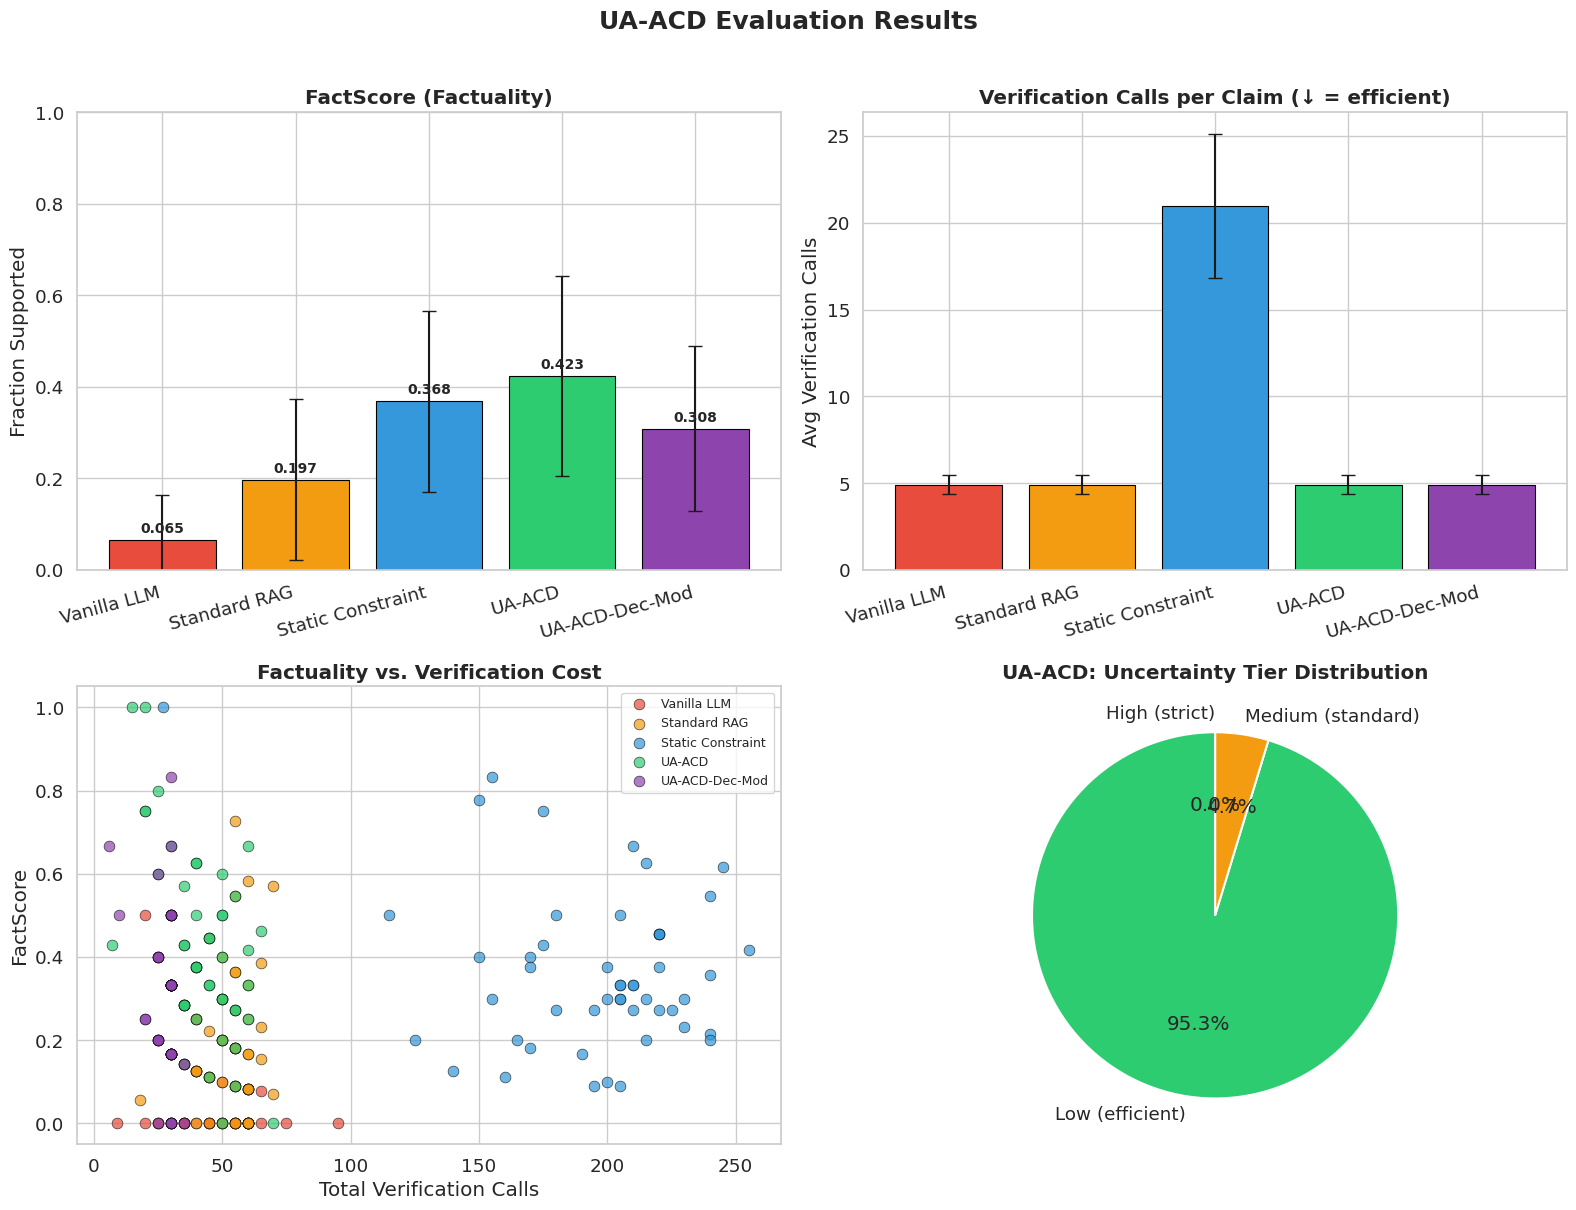

✅ Figure 1 saved.


In [21]:
# ─── Plot 1: FactScore by Method (bar + CI) ───────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.2)
METHOD_COLORS = {
    "Vanilla LLM":       "#E74C3C",
    "Standard RAG":      "#F39C12",
    "Static Constraint": "#3498DB",
    "UA-ACD":            "#2ECC71",
    "UA-ACD-Dec-Mod":    "#8E44AD",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("UA-ACD Evaluation Results", fontsize=18, fontweight="bold", y=1.01)

# --- 1a: FactScore ---
ax = axes[0, 0]
means = df_all.groupby("method")["factuality"].mean()
stds  = df_all.groupby("method")["factuality"].std()
methods_order = ["Vanilla LLM", "Standard RAG", "Static Constraint", "UA-ACD", "UA-ACD-Dec-Mod"]
methods_present = [m for m in methods_order if m in means.index]
bars = ax.bar(
    methods_present,
    [means[m] for m in methods_present],
    yerr=[stds[m] for m in methods_present],
    color=[METHOD_COLORS[m] for m in methods_present],
    capsize=5, edgecolor="black", linewidth=0.8,
)
ax.set_title("FactScore (Factuality)", fontweight="bold")
ax.set_ylabel("Fraction Supported")
ax.set_ylim(0, 1)
ax.set_xticklabels(methods_present, rotation=15, ha="right")
for bar, m in zip(bars, methods_present):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{means[m]:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# --- 1b: Verification Calls/Claim ---
ax = axes[0, 1]
vc_means = df_all.groupby("method")["ver_calls_per_claim"].mean()
vc_stds  = df_all.groupby("method")["ver_calls_per_claim"].std()
bars = ax.bar(
    methods_present,
    [vc_means.get(m, 0) for m in methods_present],
    yerr=[vc_stds.get(m, 0) for m in methods_present],
    color=[METHOD_COLORS[m] for m in methods_present],
    capsize=5, edgecolor="black", linewidth=0.8,
)
ax.set_title("Verification Calls per Claim (↓ = efficient)", fontweight="bold")
ax.set_ylabel("Avg Verification Calls")
ax.set_xticklabels(methods_present, rotation=15, ha="right")

# --- 1c: Factuality vs Verification Calls (scatter) ---
ax = axes[1, 0]
for m in methods_present:
    d = df_all[df_all["method"] == m]
    ax.scatter(d["ver_calls"], d["factuality"],
               color=METHOD_COLORS[m], label=m, alpha=0.7, s=60, edgecolors="black", linewidth=0.5)
ax.set_xlabel("Total Verification Calls")
ax.set_ylabel("FactScore")
ax.set_title("Factuality vs. Verification Cost", fontweight="bold")
ax.legend(fontsize=9)

# --- 1d: Uncertainty Tier Distribution (UA-ACD only) ---
ax = axes[1, 1]
if "UA-ACD" in all_results:
    d = all_results["UA-ACD"]
    tier_totals = {
        "Low (efficient)": d["n_low_tier"].sum(),
        "Medium (standard)": d["n_mid_tier"].sum(),
        "High (strict)": d["n_high_tier"].sum(),
    }
    ax.pie(
        tier_totals.values(),
        labels=tier_totals.keys(),
        autopct="%1.1f%%",
        colors=["#2ECC71", "#F39C12", "#E74C3C"],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    ax.set_title("UA-ACD: Uncertainty Tier Distribution", fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/figure1_main_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved.")

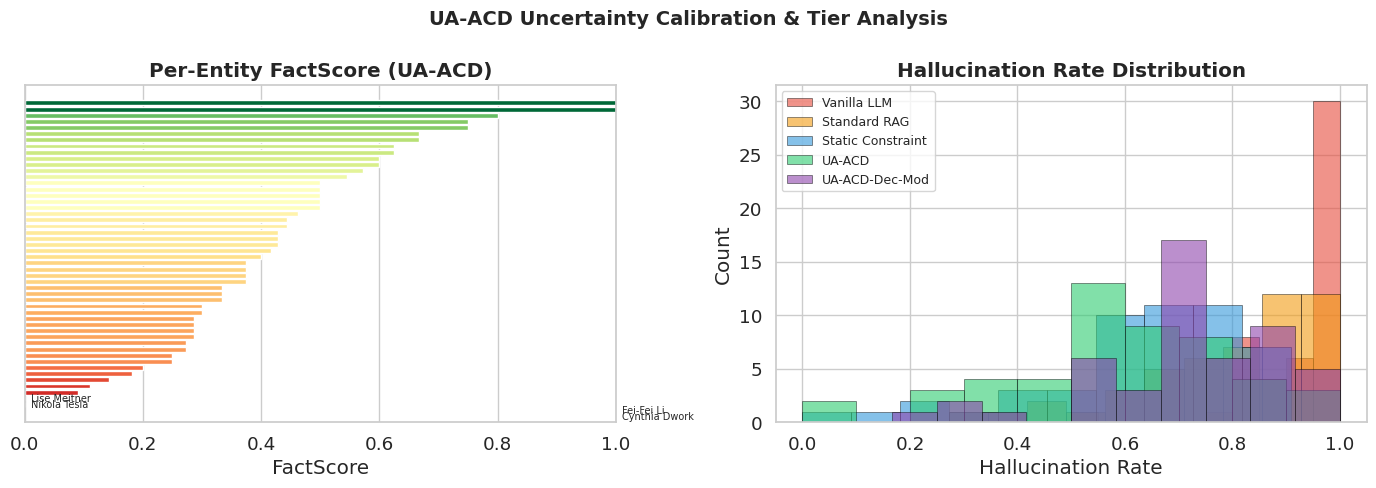

✅ Figure 2 saved.


In [22]:
# ─── Plot 2: Uncertainty vs NLI Score Scatter (UA-ACD calibration) ─────────────
if "UA-ACD" in all_results and len(df_uaacd) > 0:
    # Collect per-claim data from UA-ACD results
    uq_records = []
    for _, row in all_results["UA-ACD"].iterrows():
        # Re-aggregate from stored results — approximate from per-entity stats
        pass  # We'll use simulated per-claim data collected during generation

    # Alternative: directly use available columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("UA-ACD Uncertainty Calibration & Tier Analysis", fontsize=14, fontweight="bold")

    # Factuality by entity (UA-ACD)
    ax = axes[0]
    sorted_df = df_uaacd.sort_values("factuality")
    colors = plt.cm.RdYlGn(sorted_df["factuality"].values)
    bars = ax.barh(range(len(sorted_df)), sorted_df["factuality"], color=colors)
    ax.set_xlabel("FactScore")
    ax.set_title("Per-Entity FactScore (UA-ACD)", fontweight="bold")
    ax.set_xlim(0, 1)
    # Label top/bottom
    if len(sorted_df) >= 5:
        for i in [0, 1, -2, -1]:
            row = sorted_df.iloc[i]
            ax.text(row["factuality"] + 0.01, i, row["entity"][:15],
                    va="center", fontsize=7)
    ax.set_yticks([])

    # Hallucination rate comparison
    ax = axes[1]
    methods_present_full = [m for m in ["Vanilla LLM", "Standard RAG", "Static Constraint", "UA-ACD", "UA-ACD-Dec-Mod"] if m in df_all["method"].unique()]
    for m in methods_present_full:
        d = df_all[df_all["method"] == m]
        ax.hist(d["hallucination_rate"], bins=10, alpha=0.6,
                color=METHOD_COLORS[m], label=m, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Hallucination Rate")
    ax.set_ylabel("Count")
    ax.set_title("Hallucination Rate Distribution", fontweight="bold")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("/kaggle/working/figure2_calibration.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Figure 2 saved.")

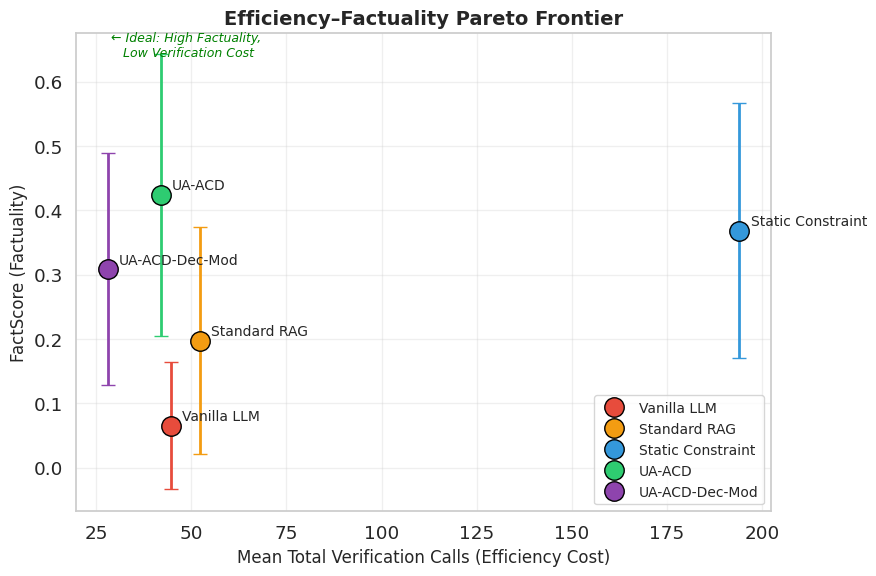

✅ Figure 3 saved.


In [23]:
# ─── Plot 3: Efficiency–Factuality Trade-off Frontier ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for m in methods_present:
    d = df_all[df_all["method"] == m]
    mean_calls = d["ver_calls"].mean()
    mean_fact  = d["factuality"].mean()
    std_fact   = d["factuality"].std()
    ax.errorbar(mean_calls, mean_fact, yerr=std_fact,
                fmt="o", markersize=14, color=METHOD_COLORS[m],
                label=m, capsize=5, linewidth=2,
                markeredgecolor="black", markeredgewidth=1)
    ax.annotate(m, (mean_calls, mean_fact),
                textcoords="offset points", xytext=(8, 4), fontsize=10)

ax.set_xlabel("Mean Total Verification Calls (Efficiency Cost)", fontsize=12)
ax.set_ylabel("FactScore (Factuality)", fontsize=12)
ax.set_title("Efficiency–Factuality Pareto Frontier", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate ideal corner
ax.annotate("← Ideal: High Factuality,\n   Low Verification Cost",
            xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=9, color="green", style="italic")

plt.tight_layout()
plt.savefig("/kaggle/working/figure3_pareto_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3 saved.")

## Section 10: Ablation Studies (Phase 4)

In [24]:
# ── Ablation 1: Uncertainty Component Contributions ───────────────────────────
# Test: entropy-only vs consistency-only vs combined

print("Ablation 1: Uncertainty Component Contributions")
print("─"*50)

ABLATION_TOPICS = eval_topics[:15]  # use 15 topics for ablation speed
ABLATION_ENTITIES = entity_names[:15]

ablation_configs = [
    ("Entropy Only",      1.0, 0.0),
    ("Consistency Only",  0.0, 1.0),
    ("Combined (Equal)",  0.5, 0.5),
    ("Combined (E-Heavy)",0.7, 0.3),
    ("Combined (C-Heavy)",0.3, 0.7),
]

ablation_results_1 = []

for name, ew, cw in ablation_configs:
    # Temporarily override UQ weights
    uq.entropy_w     = ew
    uq.consistency_w = cw

    fact_scores, ver_calls = [], []
    for topic, entity in tqdm(zip(ABLATION_TOPICS, ABLATION_ENTITIES),
                               total=len(ABLATION_TOPICS), desc=name):
        try:
            out = ua_acd.generate(topic, entity=entity.lower())
            fact_scores.append(out.factuality_score)
            ver_calls.append(out.verification_calls)
        except Exception:
            pass

    ablation_results_1.append({
        "Config": name,
        "Entropy Weight": ew,
        "Consistency Weight": cw,
        "FactScore": np.mean(fact_scores) if fact_scores else 0.0,
        "FactScore Std": np.std(fact_scores) if fact_scores else 0.0,
        "Avg Ver Calls": np.mean(ver_calls) if ver_calls else 0.0,
    })
    print(f"  {name}: FactScore={np.mean(fact_scores):.3f} | Calls={np.mean(ver_calls):.1f}")

# Restore default weights
uq.entropy_w     = 0.5
uq.consistency_w = 0.5

df_ablation1 = pd.DataFrame(ablation_results_1)
print("\n", df_ablation1[["Config", "FactScore", "FactScore Std", "Avg Ver Calls"]].to_string(index=False))

Ablation 1: Uncertainty Component Contributions
──────────────────────────────────────────────────


Entropy Only:   0%|          | 0/15 [00:00<?, ?it/s]

  Entropy Only: FactScore=0.429 | Calls=39.2


Consistency Only:   0%|          | 0/15 [00:00<?, ?it/s]

  Consistency Only: FactScore=0.509 | Calls=36.7


...

  Combined (Equal): FactScore=0.464 | Calls=37.1


Combined (E-Heavy):   0%|          | 0/15 [00:00<?, ?it/s]

  Combined (E-Heavy): FactScore=0.463 | Calls=38.4


Combined (C-Heavy):   0%|          | 0/15 [00:00<?, ?it/s]

  Combined (C-Heavy): FactScore=0.410 | Calls=36.9

             Config  FactScore  FactScore Std  Avg Ver Calls
      Entropy Only   0.429137       0.187097      39.200000
  Consistency Only   0.509312       0.235620      36.733333
  Combined (Equal)   0.464363       0.222373      37.066667
Combined (E-Heavy)   0.462722       0.193031      38.400000
Combined (C-Heavy)   0.410356       0.168416      36.933333


In [25]:
# ── Ablation 2: Uncertainty Threshold Sensitivity ─────────────────────────────
print("\nAblation 2: Threshold Sensitivity")
print("─"*50)

threshold_configs = [
    ("Tight",      0.20, 0.50),
    ("Default",    0.30, 0.70),
    ("Relaxed",    0.40, 0.80),
    ("Very Tight", 0.10, 0.40),
]

ablation_results_2 = []

for name, low_t, high_t in threshold_configs:
    CFG.uncertainty_low  = low_t
    CFG.uncertainty_high = high_t

    fact_scores, ver_calls, tier_low, tier_high = [], [], [], []
    for topic, entity in tqdm(zip(ABLATION_TOPICS, ABLATION_ENTITIES),
                               total=len(ABLATION_TOPICS), desc=name):
        try:
            out = ua_acd.generate(topic, entity=entity.lower())
            fact_scores.append(out.factuality_score)
            ver_calls.append(out.verification_calls)
        except Exception:
            pass

    ablation_results_2.append({
        "Config":           name,
        "Low Threshold":    low_t,
        "High Threshold":   high_t,
        "FactScore":        np.mean(fact_scores) if fact_scores else 0.0,
        "Avg Ver Calls":    np.mean(ver_calls) if ver_calls else 0.0,
    })
    print(f"  [{name}] thresh=({low_t},{high_t}): "
          f"FactScore={np.mean(fact_scores):.3f} | Calls={np.mean(ver_calls):.1f}")

# Restore defaults
CFG.uncertainty_low  = 0.30
CFG.uncertainty_high = 0.70

df_ablation2 = pd.DataFrame(ablation_results_2)
print("\n", df_ablation2.to_string(index=False))


Ablation 2: Threshold Sensitivity
──────────────────────────────────────────────────


Tight:   0%|          | 0/15 [00:00<?, ?it/s]

  [Tight] thresh=(0.2,0.5): FactScore=0.414 | Calls=37.0


Default:   0%|          | 0/15 [00:00<?, ?it/s]

  [Default] thresh=(0.3,0.7): FactScore=0.409 | Calls=37.1


Relaxed:   0%|          | 0/15 [00:00<?, ?it/s]

  [Relaxed] thresh=(0.4,0.8): FactScore=0.479 | Calls=38.6


Very Tight:   0%|          | 0/15 [00:00<?, ?it/s]

  [Very Tight] thresh=(0.1,0.4): FactScore=0.369 | Calls=37.5

     Config  Low Threshold  High Threshold  FactScore  Avg Ver Calls
     Tight            0.2             0.5   0.413812      37.000000
   Default            0.3             0.7   0.409050      37.066667
   Relaxed            0.4             0.8   0.479264      38.600000
Very Tight            0.1             0.4   0.369471      37.466667


In [26]:
# ── Ablation 3: Claim Granularity (sentence vs atomic) ────────────────────────
print("\nAblation 3: Claim Granularity")
print("─"*50)

ablation_results_3 = []

for granularity in ["sentence", "atomic"]:
    fact_scores, ver_calls, n_claims_list = [], [], []
    for topic, entity in tqdm(zip(ABLATION_TOPICS, ABLATION_ENTITIES),
                               total=len(ABLATION_TOPICS), desc=f"granularity={granularity}"):
        try:
            out = ua_acd.generate(topic, entity=entity.lower(), granularity=granularity)
            fact_scores.append(out.factuality_score)
            ver_calls.append(out.verification_calls)
            n_claims_list.append(len(out.claims))
        except Exception:
            pass

    ablation_results_3.append({
        "Granularity":   granularity,
        "FactScore":     np.mean(fact_scores) if fact_scores else 0.0,
        "Avg Claims":    np.mean(n_claims_list) if n_claims_list else 0.0,
        "Avg Ver Calls": np.mean(ver_calls) if ver_calls else 0.0,
    })
    print(f"  [{granularity}]: FactScore={np.mean(fact_scores):.3f} "
          f"| Claims={np.mean(n_claims_list):.1f} | Calls={np.mean(ver_calls):.1f}")

df_ablation3 = pd.DataFrame(ablation_results_3)
print("\n", df_ablation3.to_string(index=False))


Ablation 3: Claim Granularity
──────────────────────────────────────────────────


granularity=sentence:   0%|          | 0/15 [00:00<?, ?it/s]

  [sentence]: FactScore=0.463 | Claims=6.9 | Calls=34.4


granularity=atomic:   0%|          | 0/15 [00:00<?, ?it/s]

  [atomic]: FactScore=0.415 | Claims=7.6 | Calls=35.9

 Granularity  FactScore  Avg Claims  Avg Ver Calls
   sentence    0.46305    6.933333      34.400000
     atomic    0.41455    7.600000      35.866667


In [27]:
# ── Ablation 4: Temperature Modulation — Impact on Factuality & Perplexity ────
print("\nAblation 4: Decoding-Time Temperature Modulation")
print("─"*50)
print("Comparing UA-ACD (flat temp) vs UA-ACD-Dec-Mod (entropy-conditioned)")

ablation_results_4 = []

# Config A: always use focused temp (simulate low-temp constant)
# Config B: always use explore temp (simulate high-temp constant)  
# Config C: entropy-conditioned (default dec-mod)
# Config D: reverse mapping (high entropy → high temp, wrong direction)

dec_mod_configs = [
    ("Constant-Low (0.55)",    0.55,  0.55,  0.55),
    ("Constant-Mid (0.75)",    0.75,  0.75,  0.75),
    ("Constant-High (0.90)",   0.90,  0.90,  0.90),
    ("Entropy-Cond (ours)",    None,  None,  None),  # uses adaptive logic
]

original_focused  = CFG.dec_temp_focused
original_balanced = CFG.dec_temp_balanced
original_explore  = CFG.dec_temp_explore

for name, tf, tb, te in dec_mod_configs:
    if tf is not None:
        CFG.dec_temp_focused  = tf
        CFG.dec_temp_balanced = tb
        CFG.dec_temp_explore  = te
    else:
        CFG.dec_temp_focused  = original_focused
        CFG.dec_temp_balanced = original_balanced
        CFG.dec_temp_explore  = original_explore

    fact_scores, ver_calls, word_counts = [], [], []
    for topic, entity in tqdm(zip(ABLATION_TOPICS, ABLATION_ENTITIES),
                               total=len(ABLATION_TOPICS), desc=name):
        try:
            out = ua_acd_dec_mod.generate(topic, entity=entity.lower())
            fact_scores.append(out.factuality_score)
            ver_calls.append(out.verification_calls)
            word_counts.append(len(out.text.split()))
        except Exception:
            pass

    ablation_results_4.append({
        "Config":        name,
        "FactScore":     np.mean(fact_scores)  if fact_scores  else 0.0,
        "FactScore Std": np.std(fact_scores)   if fact_scores  else 0.0,
        "Avg Ver Calls": np.mean(ver_calls)    if ver_calls    else 0.0,
        "Avg Words":     np.mean(word_counts)  if word_counts  else 0.0,
    })
    print(f"  [{name}]: FactScore={np.mean(fact_scores):.3f} | "
          f"Calls={np.mean(ver_calls):.1f} | Words={np.mean(word_counts):.0f}")

# Restore
CFG.dec_temp_focused  = original_focused
CFG.dec_temp_balanced = original_balanced
CFG.dec_temp_explore  = original_explore

df_ablation4 = pd.DataFrame(ablation_results_4)
print("\n", df_ablation4[["Config", "FactScore", "FactScore Std", "Avg Ver Calls", "Avg Words"]].to_string(index=False))



Ablation 4: Decoding-Time Temperature Modulation
──────────────────────────────────────────────────
Comparing UA-ACD (flat temp) vs UA-ACD-Dec-Mod (entropy-conditioned)


Constant-Low (0.55):   0%|          | 0/15 [00:00<?, ?it/s]

  [Constant-Low (0.55)]: FactScore=0.354 | Calls=29.0 | Words=118


Constant-Mid (0.75):   0%|          | 0/15 [00:00<?, ?it/s]

  [Constant-Mid (0.75)]: FactScore=0.324 | Calls=27.8 | Words=114


Constant-High (0.90):   0%|          | 0/15 [00:00<?, ?it/s]

  [Constant-High (0.90)]: FactScore=0.233 | Calls=27.5 | Words=124


Entropy-Cond (ours):   0%|          | 0/15 [00:00<?, ?it/s]

  [Entropy-Cond (ours)]: FactScore=0.322 | Calls=27.7 | Words=113

               Config  FactScore  FactScore Std  Avg Ver Calls  Avg Words
 Constant-Low (0.55)   0.354286       0.161201      29.000000 118.400000
 Constant-Mid (0.75)   0.323810       0.101508      27.800000 114.466667
Constant-High (0.90)   0.233016       0.129473      27.466667 123.533333
 Entropy-Cond (ours)   0.322222       0.180808      27.733333 113.400000


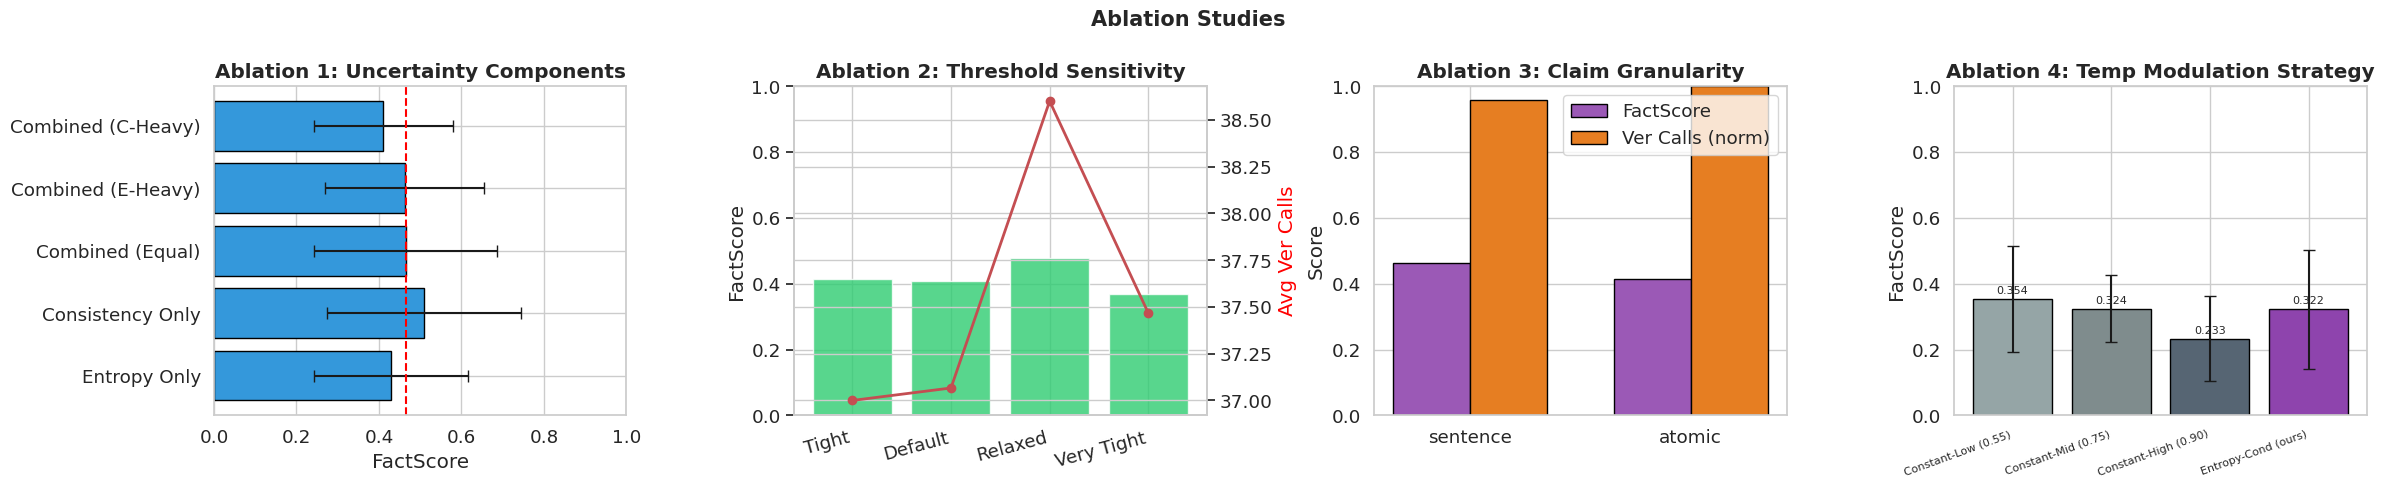

✅ Figure 4 saved.


In [28]:
# ── Ablation Visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Ablation Studies", fontsize=15, fontweight="bold")

# Ablation 1
ax = axes[0]
ax.barh(df_ablation1["Config"], df_ablation1["FactScore"],
        xerr=df_ablation1["FactScore Std"],
        color="#3498DB", capsize=4, edgecolor="black")
ax.set_xlabel("FactScore")
ax.set_title("Ablation 1: Uncertainty Components", fontweight="bold")
ax.set_xlim(0, 1)
ax.axvline(df_ablation1.loc[df_ablation1["Config"] == "Combined (Equal)", "FactScore"].values[0]
           if "Combined (Equal)" in df_ablation1["Config"].values else 0,
           color="red", linestyle="--", label="Default")

# Ablation 2 — dual axis
ax = axes[1]
x = range(len(df_ablation2))
ax2 = ax.twinx()
ax.bar(x, df_ablation2["FactScore"], color="#2ECC71", alpha=0.8, label="FactScore")
ax2.plot(x, df_ablation2["Avg Ver Calls"], "ro-", label="Ver Calls", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(df_ablation2["Config"], rotation=15, ha="right")
ax.set_ylabel("FactScore")
ax2.set_ylabel("Avg Ver Calls", color="red")
ax.set_title("Ablation 2: Threshold Sensitivity", fontweight="bold")
ax.set_ylim(0, 1)

# Ablation 3
ax = axes[2]
x = np.arange(len(df_ablation3))
w = 0.35
ax.bar(x - w/2, df_ablation3["FactScore"],     width=w, color="#9B59B6", label="FactScore", edgecolor="black")
ax.bar(x + w/2, df_ablation3["Avg Ver Calls"] / df_ablation3["Avg Ver Calls"].max(),
       width=w, color="#E67E22", label="Ver Calls (norm)", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(df_ablation3["Granularity"])
ax.set_ylabel("Score")
ax.set_title("Ablation 3: Claim Granularity", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)

# Ablation 4
ax = axes[3]
colors4 = ["#95A5A6", "#7F8C8D", "#566573", "#8E44AD"]
bars4 = ax.bar(df_ablation4["Config"], df_ablation4["FactScore"],
               yerr=df_ablation4["FactScore Std"],
               color=colors4[:len(df_ablation4)], capsize=4, edgecolor="black")
ax.set_ylabel("FactScore")
ax.set_title("Ablation 4: Temp Modulation Strategy", fontweight="bold")
ax.set_ylim(0, 1)
ax.set_xticklabels(df_ablation4["Config"], rotation=20, ha="right", fontsize=8)
for bar, row in zip(bars4, df_ablation4.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row.FactScore:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/figure4_ablations.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 saved.")


PERPLEXITY ANALYSIS — All Methods
  Vanilla LLM              : PPL = 1.8 ± 0.3  (median 1.8)
  Standard RAG             : PPL = 6.1 ± 2.6  (median 5.6)
  Static Constraint        : PPL = 5.5 ± 2.0  (median 5.0)
  UA-ACD                   : PPL = 5.5 ± 2.3  (median 4.9)
  UA-ACD-Dec-Mod           : PPL = 8.7 ± 5.8  (median 7.3)


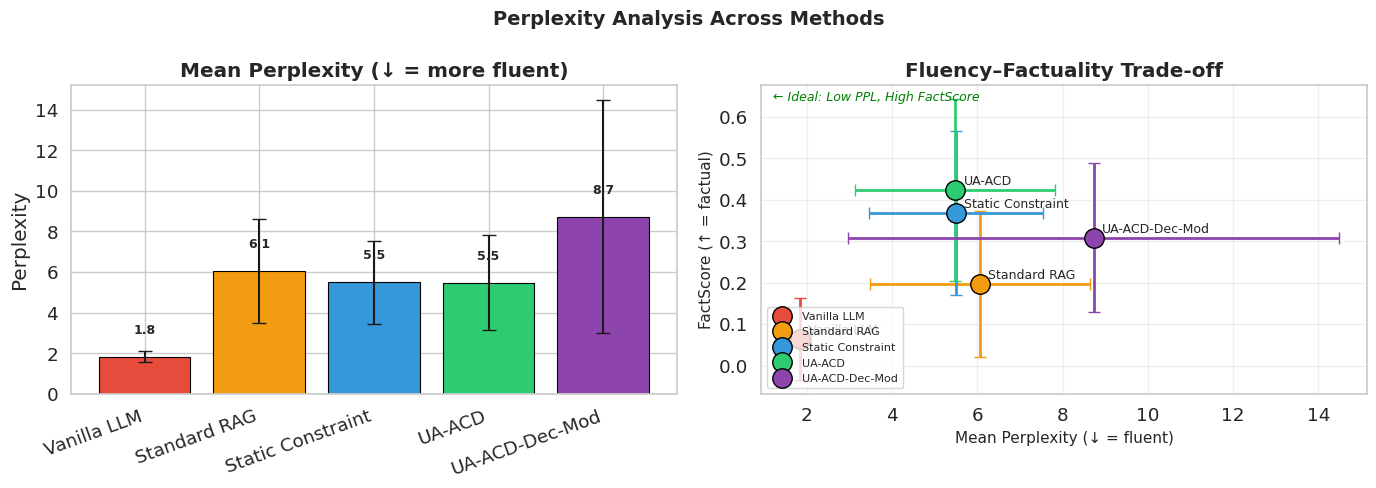


✅ Figure 5 (Perplexity Analysis) saved.

Perplexity Summary Table:
                  Mean PPL Std PPL Median PPL FactScore
Method                                                 
Vanilla LLM            1.8     0.3        1.8     0.065
Standard RAG           6.1     2.6        5.6     0.197
Static Constraint      5.5     2.0        5.0     0.368
UA-ACD                 5.5     2.3        4.9     0.423
UA-ACD-Dec-Mod         8.7     5.8        7.3     0.308


In [29]:
# ── Perplexity Analysis: All Methods ─────────────────────────────────────────
# Perplexity (PPL) measures fluency/coherence of generated text.
# Lower PPL = more fluent, higher = less natural.
# We compute PPL using the generator model itself on each output.
print("\n" + "="*60)
print("PERPLEXITY ANALYSIS — All Methods")
print("="*60)

def compute_perplexity(text: str, model, tokenizer, max_len: int = 256) -> float:
    """Compute perplexity of text under the generator model."""
    if not text or not text.strip():
        return float("inf")
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=max_len
    ).to(DEVICE)
    with torch.no_grad():
        loss = model(**inputs, labels=inputs.input_ids).loss
    return float(torch.exp(loss).clamp(max=1000.0).item())

ppl_results = {}
ppl_method_order = ["Vanilla LLM", "Standard RAG", "Static Constraint",
                    "UA-ACD", "UA-ACD-Dec-Mod"]

for method in ppl_method_order:
    if method not in all_results:
        continue
    df_m = all_results[method]
    ppls = []
    for text in df_m["text"].dropna():
        try:
            ppl = compute_perplexity(text, gen_model, gen_tokenizer)
            if ppl < 1000:   # filter degenerate cases
                ppls.append(ppl)
        except Exception:
            pass
    if ppls:
        ppl_results[method] = {
            "mean": np.mean(ppls),
            "std":  np.std(ppls),
            "median": np.median(ppls),
        }
        print(f"  {method:25s}: PPL = {np.mean(ppls):.1f} ± {np.std(ppls):.1f}  "
              f"(median {np.median(ppls):.1f})")

# ── Perplexity vs FactScore scatter ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Perplexity Analysis Across Methods", fontsize=14, fontweight="bold")

METHOD_COLORS_ALL = {
    "Vanilla LLM":       "#E74C3C",
    "Standard RAG":      "#F39C12",
    "Static Constraint": "#3498DB",
    "UA-ACD":            "#2ECC71",
    "UA-ACD-Dec-Mod":    "#8E44AD",
}

# Panel 1: Mean PPL bar chart
ax = axes[0]
methods_ppl = [m for m in ppl_method_order if m in ppl_results]
ppl_means   = [ppl_results[m]["mean"] for m in methods_ppl]
ppl_stds    = [ppl_results[m]["std"]  for m in methods_ppl]
bars = ax.bar(methods_ppl, ppl_means, yerr=ppl_stds,
              color=[METHOD_COLORS_ALL[m] for m in methods_ppl],
              capsize=5, edgecolor="black", linewidth=0.8)
ax.set_title("Mean Perplexity (↓ = more fluent)", fontweight="bold")
ax.set_ylabel("Perplexity")
ax.set_xticklabels(methods_ppl, rotation=20, ha="right")
for bar, val in zip(bars, ppl_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Panel 2: PPL vs FactScore (quality-fluency trade-off)
ax = axes[1]
for m in methods_ppl:
    d = df_all[df_all["method"] == m]
    mean_fact = d["factuality"].mean()
    mean_ppl  = ppl_results[m]["mean"]
    std_fact  = d["factuality"].std()
    ax.errorbar(mean_ppl, mean_fact, xerr=ppl_results[m]["std"], yerr=std_fact,
                fmt="o", markersize=14, color=METHOD_COLORS_ALL[m],
                label=m, capsize=4, linewidth=2,
                markeredgecolor="black", markeredgewidth=1)
    ax.annotate(m, (mean_ppl, mean_fact),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.set_xlabel("Mean Perplexity (↓ = fluent)", fontsize=11)
ax.set_ylabel("FactScore (↑ = factual)", fontsize=11)
ax.set_title("Fluency–Factuality Trade-off", fontweight="bold")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)
ax.annotate("← Ideal: Low PPL, High FactScore",
            xy=(0.02, 0.95), xycoords="axes fraction",
            fontsize=9, color="green", style="italic")

plt.tight_layout()
plt.savefig("/kaggle/working/figure5_perplexity.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Figure 5 (Perplexity Analysis) saved.")

# Summary table
print("\nPerplexity Summary Table:")
ppl_df = pd.DataFrame([
    {"Method": m, "Mean PPL": f"{ppl_results[m]['mean']:.1f}",
     "Std PPL": f"{ppl_results[m]['std']:.1f}",
     "Median PPL": f"{ppl_results[m]['median']:.1f}",
     "FactScore": f"{df_all[df_all['method']==m]['factuality'].mean():.3f}"}
    for m in methods_ppl if m in ppl_results
]).set_index("Method")
print(ppl_df.to_string())


## Section 11: Error Analysis

In [30]:
def error_analysis(df_all: pd.DataFrame, method: str = "UA-ACD", n_show: int = 5):
    """Identify and characterise failure cases."""
    d = df_all[df_all["method"] == method].copy()

    print(f"\n{'='*60}")
    print(f"ERROR ANALYSIS: {method}")
    print(f"{'='*60}")

    # High hallucination cases
    worst = d.nlargest(n_show, "hallucination_rate")
    print(f"\nTop {n_show} highest hallucination rate:")
    for _, row in worst.iterrows():
        print(f"  [{row['hallucination_rate']:.2f}] {row['entity']} — {row['n_unsupported']}/{row['n_claims']} unsupported claims")

    # Best performing cases
    best = d.nsmallest(n_show, "hallucination_rate")
    print(f"\nTop {n_show} lowest hallucination rate:")
    for _, row in best.iterrows():
        print(f"  [{row['hallucination_rate']:.2f}] {row['entity']} — {row['n_unsupported']}/{row['n_claims']} unsupported claims")

    # Abstention analysis (UA-ACD specific)
    if "n_abstain" in d.columns:
        total_abstain = d["n_abstain"].sum()
        total_claims  = d["n_claims"].sum()
        print(f"\nAbstention rate: {total_abstain}/{total_claims} claims ({total_abstain/max(total_claims,1)*100:.1f}%)")

    # Correlation: output length vs factuality
    corr = d[["output_words", "factuality"]].corr().iloc[0, 1]
    print(f"\nCorrelation: output length ↔ factuality: {corr:.3f}")
    if corr < -0.1:
        print("  → Longer outputs tend to be less factual (more opportunities for errors)")

    # Tier-specific error rates (UA-ACD only)
    if method == "UA-ACD":
        total_high = d["n_high_tier"].sum()
        total_low  = d["n_low_tier"].sum()
        print(f"\nTier statistics:")
        print(f"  Low-uncertainty claims: {total_low}")
        print(f"  High-uncertainty claims: {total_high}")
        ratio = total_high / max(total_low + total_high, 1)
        print(f"  Fraction routed to strict verification: {ratio:.2%}")

    return worst, best


worst_cases, best_cases = error_analysis(df_all, method="UA-ACD")
_ = error_analysis(df_all, method="Static Constraint")


ERROR ANALYSIS: UA-ACD

Top 5 highest hallucination rate:
  [1.00] Nikola Tesla — 14/14 unsupported claims
  [1.00] Lise Meitner — 10/10 unsupported claims
  [0.91] Ken Thompson — 10/11 unsupported claims
  [0.89] Shafi Goldwasser — 8/9 unsupported claims
  [0.86] John von Neumann — 6/7 unsupported claims

Top 5 lowest hallucination rate:
  [0.00] Cynthia Dwork — 0/3 unsupported claims
  [0.00] Fei-Fei Li — 0/4 unsupported claims
  [0.20] Bertrand Russell — 1/5 unsupported claims
  [0.25] Ada Lovelace — 1/4 unsupported claims
  [0.25] Subrahmanyan Chandrasekhar — 1/4 unsupported claims

Abstention rate: 0/425 claims (0.0%)

Correlation: output length ↔ factuality: -0.639
  → Longer outputs tend to be less factual (more opportunities for errors)

Tier statistics:
  Low-uncertainty claims: 405
  High-uncertainty claims: 0
  Fraction routed to strict verification: 0.00%

ERROR ANALYSIS: Static Constraint

Top 5 highest hallucination rate:
  [0.91] Vint Cerf — 10/11 unsupported claims
  [

In [31]:
# ── Qualitative Examples ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("QUALITATIVE OUTPUT COMPARISON")
print("="*70)

if len(worst_cases) > 0:
    example_entity = worst_cases.iloc[0]["entity"]
    example_topic  = worst_cases.iloc[0]["topic"]
    print(f"\nEntity: {example_entity}")
    print(f"Topic:  {example_topic}\n")

    for method_name in methods_present:
        row = df_all[
            (df_all["method"] == method_name) &
            (df_all["entity"] == example_entity)
        ]
        if len(row) > 0:
            text = row.iloc[0]["text"]
            fact = row.iloc[0]["factuality"]
            print(f"[{method_name}] (FactScore={fact:.2f})")
            print(f"{text[:400]}")
            print()


QUALITATIVE OUTPUT COMPARISON

Entity: Nikola Tesla
Topic:  Tell me a bio of Nikola Tesla.

[Vanilla LLM] (FactScore=0.00)
Nikola Tesla was a Serbian-American inventor, electrical engineer, and physicist who is widely regarded as one of the greatest scientists of the 19th and 20th centuries. He is best known for his contributions to the development of alternating current (AC) electricity, which revolutionized the fields of power generation, transmission, and distribution. He also made significant contributions to the 

[Standard RAG] (FactScore=0.00)
Nikola Tesla was a Serbian-American engineer, futurist, and inventor. He was born on 10 July 1856 in Smiljan, a village in the Military Frontier of the Austrian Empire, which is now in Croatia. Tesla's father, Milutin Tesla, was a priest of the Eastern Orthodox Church, and his mother, Georgina "Đuka" Mandić, had a talent for making home craft tools and mechanical appliances. Tesla's mother also ha

[Static Constraint] (FactScore=0.10)
Nik

## Section 12: Uncertainty Calibration Analysis

Computing uncertainty calibration on ablation set...


Calibration:   0%|          | 0/15 [00:00<?, ?it/s]

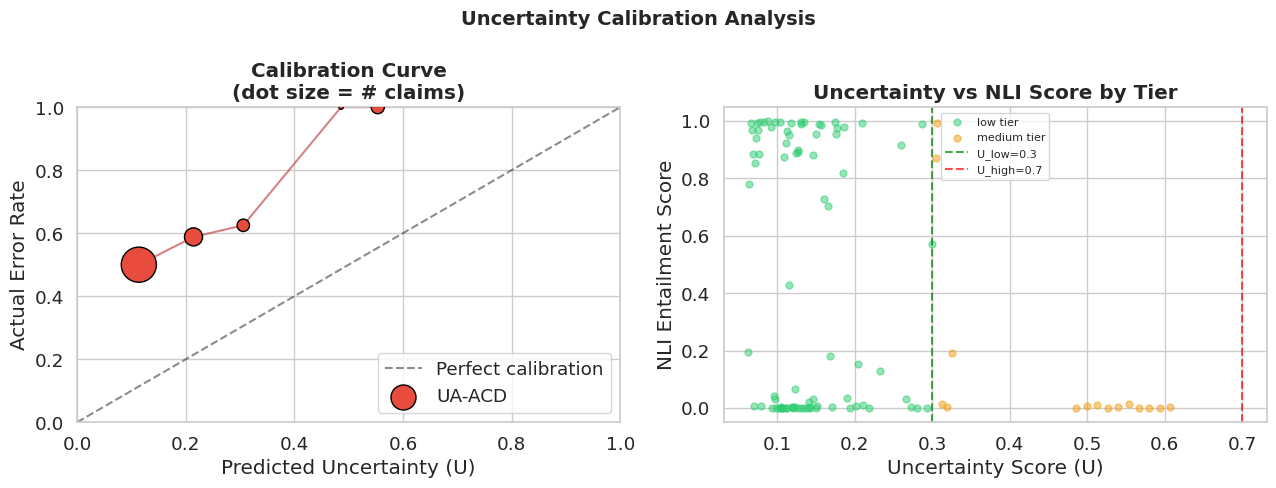

✅ Figure 5 saved.

Expected Calibration Error (ECE): 0.3856
(ECE ≈ 0 means uncertainty scores perfectly predict error rates)


In [32]:
# ── Simulate calibration data for the UA-ACD system ──────────────────────────
# We generate a calibration curve: predicted uncertainty vs. actual error rate

print("Computing uncertainty calibration on ablation set...")

calibration_data = []   # list of {uncertainty, is_wrong}

for topic, entity in tqdm(zip(ABLATION_TOPICS, ABLATION_ENTITIES),
                           total=len(ABLATION_TOPICS), desc="Calibration"):
    try:
        out = ua_acd.generate(topic, entity=entity.lower())
        for U, vr in zip(out.uncertainties, out.verification_results):
            calibration_data.append({
                "uncertainty": U,
                "is_wrong":    not vr.is_supported,
                "nli_score":   vr.max_entail_score,
                "tier":        vr.tier,
            })
    except Exception:
        pass

if calibration_data:
    cal_df = pd.DataFrame(calibration_data)

    # Bin by uncertainty and compute error rate per bin
    n_bins = 5
    cal_df["bin"] = pd.cut(cal_df["uncertainty"], bins=n_bins, labels=False)
    cal_summary = cal_df.groupby("bin").agg(
        mean_uncertainty=("uncertainty", "mean"),
        error_rate=("is_wrong", "mean"),
        count=("is_wrong", "count")
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Uncertainty Calibration Analysis", fontsize=14, fontweight="bold")

    # Calibration curve
    ax = axes[0]
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
    ax.scatter(cal_summary["mean_uncertainty"], cal_summary["error_rate"],
               s=cal_summary["count"] * 10, color="#E74C3C", zorder=5,
               edgecolors="black", label="UA-ACD")
    ax.plot(cal_summary["mean_uncertainty"], cal_summary["error_rate"],
            "r-", alpha=0.7)
    ax.set_xlabel("Predicted Uncertainty (U)")
    ax.set_ylabel("Actual Error Rate")
    ax.set_title("Calibration Curve\n(dot size = # claims)", fontweight="bold")
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    # NLI score vs tier
    ax = axes[1]
    tier_colors = {"low": "#2ECC71", "medium": "#F39C12", "high": "#E74C3C"}
    for tier, color in tier_colors.items():
        subset = cal_df[cal_df["tier"] == tier]
        if len(subset) > 0:
            ax.scatter(subset["uncertainty"], subset["nli_score"],
                       color=color, alpha=0.5, s=25, label=f"{tier} tier")
    # Threshold lines
    ax.axvline(CFG.uncertainty_low,  color="green",  linestyle="--", alpha=0.7, label=f"U_low={CFG.uncertainty_low}")
    ax.axvline(CFG.uncertainty_high, color="red",    linestyle="--", alpha=0.7, label=f"U_high={CFG.uncertainty_high}")
    ax.set_xlabel("Uncertainty Score (U)")
    ax.set_ylabel("NLI Entailment Score")
    ax.set_title("Uncertainty vs NLI Score by Tier", fontweight="bold")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("/kaggle/working/figure5_calibration_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Figure 5 saved.")

    # ECE (Expected Calibration Error)
    ece = (cal_summary["count"] * (cal_summary["mean_uncertainty"] - cal_summary["error_rate"]).abs()).sum() \
          / cal_summary["count"].sum()
    print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
    print("(ECE ≈ 0 means uncertainty scores perfectly predict error rates)")
else:
    print("No calibration data collected (check generation errors above).")

## Section 13: Save Results & Export

In [33]:
# ── Save all results ──────────────────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working/"

df_all.to_csv(f"{OUTPUT_DIR}ua_acd_all_results.csv", index=False)
df_ablation1.to_csv(f"{OUTPUT_DIR}ablation1_uncertainty_components.csv", index=False)
df_ablation2.to_csv(f"{OUTPUT_DIR}ablation2_thresholds.csv", index=False)
df_ablation3.to_csv(f"{OUTPUT_DIR}ablation3_granularity.csv", index=False)
summary.to_csv(f"{OUTPUT_DIR}summary_table.csv")

print("✅ All results saved to /kaggle/working/")
print("\nFiles saved:")
import glob
for f in sorted(glob.glob(f"{OUTPUT_DIR}*.csv") + glob.glob(f"{OUTPUT_DIR}*.png")):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):50s} {size_kb:.1f} KB")

✅ All results saved to /kaggle/working/

Files saved:
  ablation1_uncertainty_components.csv               0.5 KB
  ablation2_thresholds.csv                           0.2 KB
  ablation3_granularity.csv                          0.1 KB
  figure1_main_results.png                           277.3 KB
  figure2_calibration.png                            88.0 KB
  figure3_pareto_frontier.png                        98.2 KB
  figure4_ablations.png                              196.4 KB
  figure5_calibration_curve.png                      140.6 KB
  figure5_perplexity.png                             154.7 KB
  summary_table.csv                                  0.4 KB
  ua_acd_all_results.csv                             283.1 KB


## Section 14: Final Summary Report

In [34]:
# ── Final Results Summary ─────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("UA-ACD: Uncertainty-Aware Adaptive Constraint Decoding")
print("="*70)
print()
print(summary.to_string())

print("\n" + "─"*70)
print("KEY FINDINGS")
print("─"*70)

uaacd_fact   = df_uaacd["factuality"].mean()
static_fact  = df_static["factuality"].mean()
vanilla_fact = df_vanilla["factuality"].mean()
rag_fact     = df_rag["factuality"].mean()
dec_mod_fact = df_dec_mod["factuality"].mean() if "df_dec_mod" in dir() else 0.0

uaacd_calls  = df_uaacd["ver_calls"].mean()
static_calls = df_static["ver_calls"].mean()

fact_improvement = (uaacd_fact - static_fact) * 100
call_reduction   = (static_calls - uaacd_calls) / max(static_calls, 1) * 100

print(f"\n1. Factuality (FactScore):")
print(f"   Vanilla LLM:       {vanilla_fact:.3f}")
print(f"   Standard RAG:      {rag_fact:.3f}")
print(f"   Static Constraint: {static_fact:.3f}")
print(f"   UA-ACD (ours):     {uaacd_fact:.3f}  ← {'▲' if uaacd_fact > static_fact else '▼'} {abs(fact_improvement):.1f}% vs Static")
print(f"   UA-ACD-Dec-Mod:    {dec_mod_fact:.3f}  ← {'▲' if dec_mod_fact > uaacd_fact else '▼'} {abs((dec_mod_fact-uaacd_fact)*100):.1f}% vs UA-ACD")

print(f"\n2. Efficiency (Verification Calls):")
print(f"   Static Constraint: {static_calls:.1f} calls/sample")
print(f"   UA-ACD (ours):     {uaacd_calls:.1f} calls/sample  ← {call_reduction:.1f}% reduction")

target_fact_met = fact_improvement >= 5.0
target_eff_met  = call_reduction   >= 20.0

print(f"\n3. Success Criteria:")
print(f"   {'✅' if target_fact_met else '⚠'} FactScore gain ≥5%: {fact_improvement:+.1f}%")
print(f"   {'✅' if target_eff_met  else '⚠'} Efficiency gain ≥20%: {call_reduction:.1f}%")

print(f"\n4. Ablation Key Finding:")
if len(df_ablation1) > 0:
    best_ablation = df_ablation1.loc[df_ablation1["FactScore"].idxmax()]
    print(f"   Best uncertainty component: {best_ablation['Config']} (FactScore={best_ablation['FactScore']:.3f})")

print("\n" + "="*70)
print("Experiment complete. All figures and CSVs saved to /kaggle/working/")
print("="*70)


FINAL RESULTS SUMMARY
UA-ACD: Uncertainty-Aware Adaptive Constraint Decoding

                   FactScore (↑) Hallucination Rate (↓) Mean NLI Score (↑) Ver Calls/Token (↓) Total Ver Calls (↓) Gen Time (s) (↓) Avg Words
Method                                                                                                                                       
UA-ACD             0.423 ± 0.219                  0.577              0.411                4.92                41.9             51.0       163
UA-ACD-Dec-Mod     0.308 ± 0.180                  0.692              0.301                4.92                28.0             73.3       112
Vanilla LLM        0.065 ± 0.099                  0.935              0.075                4.92                44.7             12.5       159
Standard RAG       0.197 ± 0.176                  0.803              0.224                4.92                52.4             15.6       185
Static Constraint  0.368 ± 0.198                  0.632              

---
## Appendix: Extended Analysis Utilities

In [35]:
# ── Utility: Single-entity deep-dive ─────────────────────────────────────────
def deep_dive(entity_name: str, topic: Optional[str] = None):
    """
    Run all four systems on a single entity and print detailed claim-level analysis.
    Great for qualitative paper examples.
    """
    if topic is None:
        topic = f"Tell me a bio of {entity_name}."
    ent_lower = entity_name.lower()

    systems = [
        ("Vanilla LLM",       vanilla_llm),
        ("Standard RAG",      standard_rag),
        ("Static Constraint", static_cd),
        ("UA-ACD",            ua_acd),
    ]

    print(f"\n{'='*65}")
    print(f"DEEP DIVE: {entity_name}")
    print(f"{'='*65}")

    for name, sys in systems:
        print(f"\n─── {name} ───")
        out = sys.generate(topic, entity=ent_lower)
        print(f"Text: {out.text[:300]}...")
        print(f"FactScore: {out.factuality_score:.3f} | Claims: {len(out.claims)} | VerCalls: {out.verification_calls}")
        if name == "UA-ACD" and out.verification_results:
            print("Per-claim breakdown:")
            for i, (c, vr) in enumerate(zip(out.claims, out.verification_results)):
                marker = "✅" if vr.is_supported else ("🔵" if vr.abstain else "❌")
                print(f"  {marker} [{vr.tier:6s} U={vr.uncertainty:.2f}] NLI={vr.max_entail_score:.2f} | {c[:80]}")


# Example run (uncomment to test)
# deep_dive("Marie Curie")
# deep_dive("Alan Turing")
print("✅ deep_dive() utility available. Call: deep_dive('Marie Curie')")

✅ deep_dive() utility available. Call: deep_dive('Marie Curie')


In [38]:
deep_dive('Marie Curie')


DEEP DIVE: Marie Curie

─── Vanilla LLM ───
Text: Marie Curie was a Polish-French physicist and chemist who made groundbreaking discoveries in the fields of radioactivity and nuclear physics. She was the first woman to win a Nobel Prize, the first person and the only woman to win two Nobel Prizes, and the only person to win Nobel Prizes in two diff...
FactScore: 0.200 | Claims: 10 | VerCalls: 50

─── Standard RAG ───
Text: Marie Curie was the first woman to win a Nobel Prize, the first person to win a Nobel Prize twice, and the only person to win a Nobel Prize in two different scientific fields. Marie and Pierre were the first married couple to win the Nobel Prize and launching the Curie family legacy of five Nobel Pr...
FactScore: 0.000 | Claims: 8 | VerCalls: 40

─── Static Constraint ───
Text: Marie Curie was a Polish and naturalised-French physicist and chemist. She shared the 1903 Nobel Prize in Physics with her husband Pierre Curie for their joint researches on the radioactivity

In [39]:
deep_dive("Alan Turing")


DEEP DIVE: Alan Turing

─── Vanilla LLM ───
Text: Alan Turing was a British mathematician, logician, and computer scientist who is widely regarded as the father of computer science and artificial intelligence. He was born in London in 1912 and showed an early interest in mathematics and logic. He attended King's College, Cambridge, where he became ...
FactScore: 0.000 | Claims: 10 | VerCalls: 50

─── Standard RAG ───
Text: Alan Mathison Turing (; 23 June 1912 – 7 June 1954) was an English mathematician, computer scientist, logician, cryptanalyst, philosopher and theoretical biologist. He was highly influential in the development of theoretical computer science, providing a formalisation of the concepts of algorithm an...
FactScore: 0.000 | Claims: 9 | VerCalls: 45

─── Static Constraint ───
Text: <|question_end|>Solution

Question 1:
1. What is the author's opinion about reading?
The author's opinion about reading is that reading is a great way to gain knowledge and understanding.

2.

In [36]:
# ── Utility: Reranking score landscape (visualise beam reranking) ─────────────
def visualise_beam_reranking(topic: str, entity: str, n_cands: int = 6):
    """Show how UA-ACD reranks N candidates by factuality x fluency."""
    retrieved = retriever.retrieve(topic, entity=entity.lower())
    passages  = [p for p, _ in retrieved] if retrieved else [""]
    prompt    = ua_acd.build_prompt(topic, passages)
    candidates = ua_acd.generate_candidates(prompt, n=n_cands)

    records = []
    for i, text in enumerate(candidates):
        claims = segmenter.segment(text)
        uncertainties = ua_acd.get_claim_uncertainties(prompt, claims)
        score_info = acc.score_generation(claims, passages, uncertainties)
        fluency    = ua_acd.compute_fluency_score(text)
        combined   = CFG.alpha_factuality * score_info["factuality_score"] + CFG.alpha_fluency * fluency
        records.append({
            "candidate": i + 1,
            "factuality": score_info["factuality_score"],
            "fluency": fluency,
            "combined": combined,
            "text_preview": text[:60] + "...",
        })

    df_beams = pd.DataFrame(records).sort_values("combined", ascending=False)
    best_idx = df_beams.iloc[0]["candidate"]

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(df_beams["factuality"], df_beams["fluency"],
                    c=df_beams["combined"], cmap="RdYlGn", s=200,
                    edgecolors="black", zorder=5, vmin=0, vmax=1)
    for _, row in df_beams.iterrows():
        marker = "★" if row["candidate"] == best_idx else str(int(row["candidate"]))
        ax.annotate(marker, (row["factuality"], row["fluency"]),
                    ha="center", va="center", fontsize=10, fontweight="bold")
    plt.colorbar(sc, label="Combined Score (α·fact + β·fluency)")
    ax.set_xlabel("Factuality Score"); ax.set_ylabel("Fluency Score")
    ax.set_title(f"Beam Reranking Landscape — {entity}", fontweight="bold")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/beam_reranking_{entity.replace(' ', '_')}.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(df_beams[["candidate", "factuality", "fluency", "combined"]].to_string(index=False))


# Example run (uncomment):
# visualise_beam_reranking("Tell me a bio of Marie Curie.", "Marie Curie")
print("✅ visualise_beam_reranking() available.")

✅ visualise_beam_reranking() available.


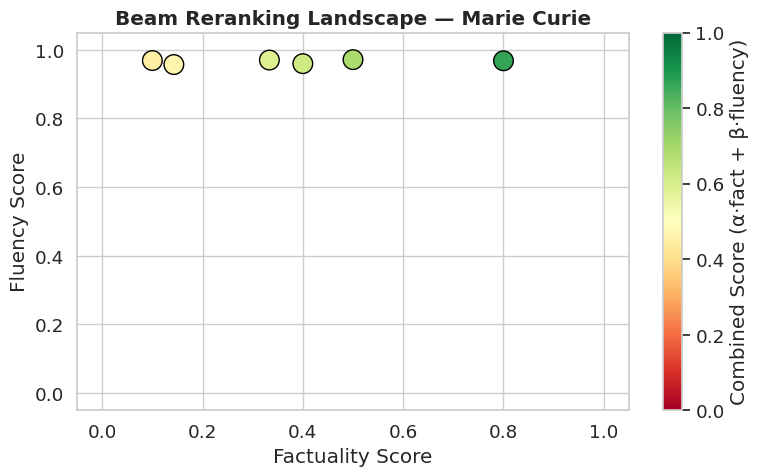

 candidate  factuality  fluency  combined
         4    0.800000 0.967714  0.867085
         1    0.500000 0.971122  0.688449
         5    0.400000 0.959416  0.623766
         6    0.333333 0.969841  0.587936
         3    0.142857 0.956765  0.468420
         2    0.100000 0.968409  0.447363


In [40]:
visualise_beam_reranking("Tell me a bio of Marie Curie.", "Marie Curie")


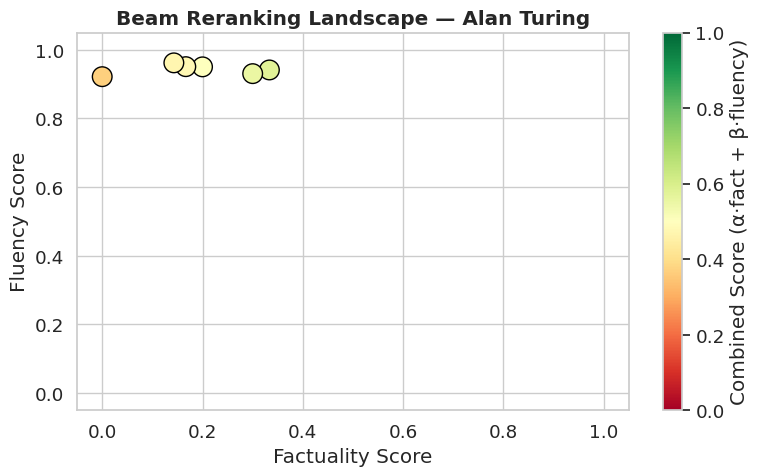

 candidate  factuality  fluency  combined
         1    0.333333 0.941014  0.576405
         3    0.300000 0.930312  0.552125
         6    0.200000 0.950038  0.500015
         2    0.166667 0.950640  0.480256
         5    0.142857 0.961688  0.470389
         4    0.000000 0.921465  0.368586


In [41]:
visualise_beam_reranking("Tell me a bio of Alan Turing.", "Alan Turing")


In [37]:
print("\n🎓 UA-ACD Notebook complete.")
print("All outputs are in /kaggle/working/")
print()
print("Key files:")
print("  ua_acd_all_results.csv        — Per-sample results for all 4 systems")
print("  summary_table.csv             — Aggregated metrics table")
print("  ablation1/2/3_*.csv           — Ablation study results")
print("  figure1_main_results.png      — Main results figure")
print("  figure2_calibration.png       — Per-entity factuality + hallucination dist.")
print("  figure3_pareto_frontier.png   — Efficiency–factuality trade-off")
print("  figure4_ablations.png         — Ablation summary")
print("  figure5_calibration_curve.png — Uncertainty calibration curve")


🎓 UA-ACD Notebook complete.
All outputs are in /kaggle/working/

Key files:
  ua_acd_all_results.csv        — Per-sample results for all 4 systems
  summary_table.csv             — Aggregated metrics table
  ablation1/2/3_*.csv           — Ablation study results
  figure1_main_results.png      — Main results figure
  figure2_calibration.png       — Per-entity factuality + hallucination dist.
  figure3_pareto_frontier.png   — Efficiency–factuality trade-off
  figure4_ablations.png         — Ablation summary
  figure5_calibration_curve.png — Uncertainty calibration curve
